# ROMS–COSiNE multi-objective TPE tuning

This notebook is the guided interface for selecting a defensible parameter search space and optimizing two objectives:

1. **Total cost** — the existing holistic cost from `CandidateParameterSetsBio.ipynb`.
2. **Bottom pH Objective** — the absolute normalized RMSD for bottom pH.

The original notebook and its Optuna study are not modified. The detailed and authoritative reference is [MULTIOBJECTIVE_TPE_GUIDE.md](MULTIOBJECTIVE_TPE_GUIDE.md).

> **Safe default:** `RUN_MODE="review"` performs analysis without modifying an Optuna study or writing candidate files.

## How to use this notebook

1. Search for **USER INPUT** and review those cells.
2. Run through the data, quality-control, and parameter-screening sections.
3. Edit `parameter_priors.csv` outside the notebook; rerun from the prior-loading section.
4. Do not prepare the study until the readiness table and proposed active search space make scientific sense.
5. Change `RUN_MODE` only for the one action you intend.

Each major section says what it does, why it matters, and what to do next. The external guide contains recovery procedures, full schemas, rationale, and maintenance context.

All generated and workflow-maintained files are organized under
`/Users/akbaskind/Desktop/Optimization/MO-BIO`. The notebook, helper, guide,
tests, and `parameter_priors.csv` remain in the project repository.

## 1. Imports

**What this does:** loads the small public interface used by the notebook.

**Behind the scenes:** stable mechanics live in `candidate_parameter_utils.py`; scientific choices remain visible here.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
import optuna

import candidate_parameter_utils as cpu

plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
pd.set_option("display.max_rows", 120)


## 2. Control panel — USER INPUT

Review this cell every time. Detailed descriptions of every variable appear in the guide's **User-input reference** section.

- `review`: no database or candidate-file writes.
- `prepare_study`: create/load the new study and import eligible historical runs.
- `generate_candidates`: create a new RUNNING batch.
- `register_results`: complete RUNNING trials whose results are available.
- `write_inputs`: write ROMS input files for existing RUNNING trials.

`DATA_LOAD_MODE="refresh"` rereads source files without replacing the cache. Use `refresh_and_save` to validate and atomically replace it.

In [2]:
# ============================================================
# USER INPUT: normal operating controls
# ============================================================
RUN_MODE = "write_inputs"      # review | prepare_study | generate_candidates | register_results | write_inputs
DATA_LOAD_MODE = "cache"       # cache | refresh | refresh_and_save
OUTPUT_DETAIL = "concise"      # concise | detailed | debug
TRIAL_BUDGET = 30              # how many model runs you can afford
N_CANDIDATES = 4
RANDOM_SEED = 42
RUN_NONLINEAR_SCREENING = True
# Learn from all valid historical numeric values, but never propose outside the prior bounds.
HISTORICAL_NUMERIC_IMPORT_POLICY = "observed_support"

# USER INPUT: display limits only; these do not change parameter eligibility or Optuna.
N_SCREENING_PARAMETERS_TO_SHOW = 25
N_CONFOUNDING_PAIRS_TO_SHOW = 15
N_PARAMETER_DISTRIBUTIONS_TO_PLOT = 20

# Pareto rank 0 is the exact front; include ranks through this value as nearby evidence.
NEAR_PARETO_RANK = 3
COST_THRESHOLD = 200.0
STRONG_CONFOUNDING_THRESHOLD = 0.80

# ============================================================
# USER INPUT: paths
# ============================================================
PROJECT_DIR = Path.cwd()
OPT_DIR = Path(os.environ.get("ROMS_OPT_DIR", Path.home() / "Desktop" / "Optimization"))
COST_DIR = Path(os.environ.get("ROMS_COST_DIR", Path.home() / "Desktop" / "COST_FILES"))
FILE_LIST = OPT_DIR / "FileNames.xlsx"
PARAMETER_LIST = OPT_DIR / "ParameterList copy.csv"

# Every generated or workflow-maintained MO-BIO file belongs under this root.
MO_BIO_OUTPUT_DIRECTORY = Path("/Users/akbaskind/Desktop/Optimization/MO-BIO")
OUTPUT_PATHS = cpu.MoBioOutputPaths(MO_BIO_OUTPUT_DIRECTORY)
cpu.ensure_mo_bio_output_layout(OUTPUT_PATHS)

RUN_CACHE_FILE = OUTPUT_PATHS.run_cache_file
PARAMETER_PRIORS_FILE = PROJECT_DIR / "parameter_priors.csv"
QUALITY_ISSUES_FILE = OUTPUT_PATHS.quality_issues_file
CORRECTIONS_FILE = OUTPUT_PATHS.corrections_file
GUIDE_FILE = PROJECT_DIR / "MULTIOBJECTIVE_TPE_GUIDE.md"
SAVE_AUDIT_OUTPUTS = True

# The multi-objective study is isolated from every legacy Optuna database.
STUDY_NAME = "model_calibration_bio_cost_bottom_ph"
STORAGE_FILE = OUTPUT_PATHS.study_database
STORAGE = f"sqlite:///{STORAGE_FILE}"
OBJECTIVE_VERSION = "cost_v3_bio_no_temp_salt__bottom_ph_nrmsd_v1"

# Candidate templates and destinations are used only in write_inputs mode.
OPTICS_TEMPLATE = Path.home() / "Desktop" / "LHS" / "bio_UMAINE15_sediment_optics_LHS1.in"
SEDIMENT_TEMPLATE = Path.home() / "Desktop" / "LHS" / "bio_UMAINE15_sedmodel_LHS1.in"
CANDIDATE_OUTPUT_DIR = OUTPUT_PATHS.candidate_input_directory
REMOTE_SEDIMENT_DIRECTORY = "/home/abaskind_uri_edu/ROMS_forcing_files/input_files/OPTUNA"
OVERWRITE_CANDIDATE_FILES = False
BASELINE_RUN_NAME = "DUMar26"

valid_run_modes = {"review", "prepare_study", "generate_candidates", "register_results", "write_inputs"}
valid_output_details = {"concise", "detailed", "debug"}
if RUN_MODE not in valid_run_modes:
    raise ValueError(f"RUN_MODE must be one of {sorted(valid_run_modes)}")
if OUTPUT_DETAIL not in valid_output_details:
    raise ValueError(f"OUTPUT_DETAIL must be one of {sorted(valid_output_details)}")
display_limits = {
    "N_SCREENING_PARAMETERS_TO_SHOW": N_SCREENING_PARAMETERS_TO_SHOW,
    "N_CONFOUNDING_PAIRS_TO_SHOW": N_CONFOUNDING_PAIRS_TO_SHOW,
    "N_PARAMETER_DISTRIBUTIONS_TO_PLOT": N_PARAMETER_DISTRIBUTIONS_TO_PLOT,
}
if any(not isinstance(value, int) or value < 1 for value in display_limits.values()):
    raise ValueError(f"Display limits must be positive integers: {display_limits}")

## 3. Scientific definitions — USER INPUT when the science changes

These mappings reproduce the reference notebook. Bottom pH contributes to total cost and is also optimized explicitly. That overlap is intentional: total cost asks whether the system is good holistically, while Bottom pH asks whether the priority target is good.

Changing any definition requires a new `OBJECTIVE_VERSION`, study name, and database.

In [3]:
include_benthic = True
exclude_some_benthic = True
benthic_targets = ["SOD", "Benthic NO3 Flux", "Benthic NH4 Flux"]
excluded_benthic_targets = ["Benthic NO3 Flux", "Benthic NH4 Flux"]

metric_info = {
    "Surface pH": ("pH_mod", "pH_obs"),
    "Bottom pH": ("pH_mod", "pH_obs"),
    "Surface Oxygen": ("oxygen_mod", "oxygen_obs"),
    "Bottom Oxygen": ("oxygen_mod", "oxygen_obs"),
    "Surface NO3": ("NO3_mod", "NO3_obs"),
    "Bottom NO3": ("NO3_mod", "NO3_obs"),
    "Surface NH4": ("NH4_mod", "NH4_obs"),
    "Bottom NH4": ("NH4_mod", "NH4_obs"),
    "Surface Si": ("Si_mod", "Si_obs"),
    "Bottom Si": ("Si_mod", "Si_obs"),
    "Secchi Depth": ("SD_mod", "SD_obs"),
    "SOD": ("sed_o2_mod", "sed_o2_obs"),
    "Benthic NO3 Flux": ("sed_no3_mod", "sed_no3_obs"),
    "Benthic NH4 Flux": ("sed_nh4_mod", "sed_nh4_obs"),
}
cost_components = {
    "Surface pH": "pH_cost", "Bottom pH": "pH_cost",
    "Surface Oxygen": "oxygen_cost", "Bottom Oxygen": "oxygen_cost",
    "Surface NO3": "NO3_cost", "Bottom NO3": "NO3_cost",
    "Surface NH4": "NH4_cost", "Bottom NH4": "NH4_cost",
    "Surface Si": "Si_cost", "Bottom Si": "Si_cost",
    "Secchi Depth": "SD_cost", "SOD": "sed_o2_cost",
    "Benthic NO3 Flux": "sed_no3_cost", "Benthic NH4 Flux": "sed_nh4_cost",
}
cost_weights = {
    "Surface pH": 2, "Bottom pH": 2,
    "Surface Oxygen": 2, "Bottom Oxygen": 2,
    "Surface NO3": 1, "Bottom NO3": 1,
    "Surface NH4": 1, "Bottom NH4": 1,
    "Surface Si": 1, "Bottom Si": 1,
    "Secchi Depth": 1, "SOD": 1,
    "Benthic NO3 Flux": 1, "Benthic NH4 Flux": 1,
}
if not include_benthic:
    metric_info = {k: v for k, v in metric_info.items() if k not in benthic_targets}
    cost_components = {k: v for k, v in cost_components.items() if k not in benthic_targets}
    cost_weights = {k: v for k, v in cost_weights.items() if k not in benthic_targets}
elif exclude_some_benthic:
    metric_info = {k: v for k, v in metric_info.items() if k not in excluded_benthic_targets}
    cost_components = {k: v for k, v in cost_components.items() if k not in excluded_benthic_targets}
    cost_weights = {k: v for k, v in cost_weights.items() if k not in excluded_benthic_targets}

CPP_OPTION_PARAMETERS = ("CACO3",)
CPP_CONDITIONAL_FLOAT_VARIABLES = {
    "CACO3": {
        "cacopf": ("cacopf",), "cacodr": ("cacodr",),
        "omega_thresh": ("omega_thresh",), "wsPCa": ("wsPCa",),
        "bUmaxCa": ("bUmaxCa_nspc0", "bUmaxCa_nspc1", "bUmaxCa_nspc2"),
    }
}
BIO_NL_TNU2_PARAMETER = "nl_tnu2_tracer9"
BIO_ADVECTION_PARAMETER = "tracer9_advection_scheme"
BIOLOGICAL_TRACER_COUNT = 15
BIO_ADVECTION_SCHEMES = {
    "Upstream3_Centered4": ("Upstream3", "Centered4"),
    "HSIMT": ("HSIMT", "HSIMT"),
    "Akima4": ("Akima4", "Akima4"),
    "MPDATA": ("MPDATA", "MPDATA"),
}
ADVECTION_INPUT_CODES = {
    "Upstream3": "U3", "Centered4": "C4", "Akima4": "A4",
    "MPDATA": "MPDATA", "HSIMT": "HSIMT",
}


## 4. Configuration check

This section is intentionally compact. It reports missing required inputs and clearly announces any mode that can write data.

**How to interpret the table:** this is a preflight checklist, not a scientific result. Confirm that the displayed mode, paths, trial budget, study identity, and objective version match your intent. Any non-`review` run mode should be treated as an explicit action request.

In [4]:
required_project_files = [PARAMETER_PRIORS_FILE, CORRECTIONS_FILE, GUIDE_FILE]
missing_project_files = [str(path) for path in required_project_files if not path.is_file()]
required_data_files = [RUN_CACHE_FILE] if DATA_LOAD_MODE == "cache" else [FILE_LIST, PARAMETER_LIST]
missing_data_files = [str(path) for path in required_data_files if not path.is_file()]

configuration_summary = pd.DataFrame([
    {"Setting": "Run mode", "Value": RUN_MODE},
    {"Setting": "Data load mode", "Value": DATA_LOAD_MODE},
    {"Setting": "Output detail", "Value": OUTPUT_DETAIL},
    {"Setting": "Trial budget", "Value": TRIAL_BUDGET},
    {"Setting": "Study", "Value": STUDY_NAME},
    {"Setting": "Output root", "Value": str(MO_BIO_OUTPUT_DIRECTORY)},
    {"Setting": "Database", "Value": str(STORAGE_FILE)},
    {"Setting": "Objective version", "Value": OBJECTIVE_VERSION},
])
display(configuration_summary.style.hide(axis="index"))
if missing_project_files or missing_data_files:
    raise FileNotFoundError(f"Missing required files: {missing_project_files + missing_data_files}")
if RUN_MODE != "review":
    print(f"ACTION MODE: {RUN_MODE}. Review the corresponding section before running it.")


# Old MO-BIO-owned paths are not fallback inputs.  Their presence means a stale
# copy may have been recreated and deserves review.
legacy_mo_bio_outputs = [
    PROJECT_DIR / "data_corrections.csv",
    PROJECT_DIR / "data_quality_issues.csv",
    OPT_DIR / "model_calibration_bio_cost_bottom_ph.db",
    OPT_DIR / "Optuna_Bio_MultiObjective_Candidates.csv",
    OPT_DIR / "Candidate_Input_Files_MultiObjective",
]
unexpected_legacy_outputs = [path for path in legacy_mo_bio_outputs if path.exists()]
if unexpected_legacy_outputs:
    print("Old MO-BIO output paths exist but will not be read:")
    for legacy_path in unexpected_legacy_outputs:
        print(f"  - {legacy_path}")

Setting,Value
Run mode,write_inputs
Data load mode,cache
Output detail,concise
Trial budget,30
Study,model_calibration_bio_cost_bottom_ph
Output root,/Users/akbaskind/Desktop/Optimization/MO-BIO
Database,/Users/akbaskind/Desktop/Optimization/MO-BIO/optuna/model_calibration_bio_cost_bottom_ph.db
Objective version,cost_v3_bio_no_temp_salt__bottom_ph_nrmsd_v1


ACTION MODE: write_inputs. Review the corresponding section before running it.


## 5. Load run data

**What this does:** uses the validated cache by default or performs a fresh source read when requested.

**What deserves attention:** unreadable files, completely missing parameters/objectives, and high costs. Routine paired-data mismatches are retained in diagnostics but are not printed in concise mode.

**How to interpret the tables:** `run_audit` is a health summary. Zero unreadable runs, zero missing files, and zero unexpectedly high costs are the desired results. A source file newer than the cache does not prove the cache is wrong, but it means the cache may be stale and a deliberate refresh should be considered. The additional tables appear only when something needs attention; they identify records to investigate rather than records the notebook has automatically repaired.

In [5]:
refresh_outputs = {}

def refresh_from_sources():
    runs = pd.read_excel(FILE_LIST)[["Run Name", "Cost File", "Station File"]].dropna()
    parameter_names = (
        pd.read_csv(PARAMETER_LIST)["Parameter Name"].dropna().astype(str).str.strip().tolist()
    )
    archive, diagnostics, failures = cpu.refresh_run_archive(
        runs,
        cost_directory=COST_DIR,
        parameter_names=parameter_names,
        metric_info=metric_info,
        cost_components=cost_components,
        cost_weights=cost_weights,
        cpp_option_names=CPP_OPTION_PARAMETERS,
        cpp_conditional_variables=CPP_CONDITIONAL_FLOAT_VARIABLES,
        biological_nl_tnu2_parameter=BIO_NL_TNU2_PARAMETER,
        biological_advection_parameter=BIO_ADVECTION_PARAMETER,
        biological_advection_schemes=BIO_ADVECTION_SCHEMES,
    )
    refresh_outputs["diagnostics"] = diagnostics
    refresh_outputs["failures"] = failures
    archive["Objective Version"] = OBJECTIVE_VERSION
    return archive

DF_raw, data_source_description = cpu.load_cached_or_refresh(
    RUN_CACHE_FILE, DATA_LOAD_MODE, refresh_from_sources
)

# Normalize provenance names from the reference cache without inventing dates.
if "Station Run Date" not in DF_raw and "Run Date" in DF_raw:
    DF_raw["Station Run Date"] = pd.to_datetime(DF_raw["Run Date"], errors="coerce")
if "Station Date Is Fallback" not in DF_raw:
    DF_raw["Station Date Is Fallback"] = DF_raw["Station Run Date"].isna()

cache_freshness = None
if DATA_LOAD_MODE == "cache" and FILE_LIST.is_file():
    source_inventory = pd.read_excel(FILE_LIST)[["Cost File", "Station File"]].dropna()
    source_files = [COST_DIR / name for column in source_inventory for name in source_inventory[column].astype(str)]
    cache_freshness = cpu.cache_status(RUN_CACHE_FILE, source_files)

unreadable = DF_raw.loc[
    DF_raw.get("Cost Status", "Success").ne("Success")
    | DF_raw.get("Parameter Status", "Success").ne("Success"),
    [column for column in ["Run Name", "Cost File", "Station File", "Cost Status", "Parameter Status"] if column in DF_raw],
]
high_cost = DF_raw.loc[
    pd.to_numeric(DF_raw["Cost"], errors="coerce").ge(COST_THRESHOLD),
    ["Run Name", "Cost"],
]
run_audit = pd.DataFrame([
    {"Check": "Data source", "Result": data_source_description},
    {"Check": "Runs loaded", "Result": len(DF_raw)},
    {"Check": "Unreadable/incomplete runs", "Result": len(unreadable)},
    {"Check": "Runs at or above cost threshold", "Result": len(high_cost)},
])
if cache_freshness is not None:
    run_audit = pd.concat([run_audit, pd.DataFrame([
        {"Check": "Cache modified UTC", "Result": cache_freshness.cache_modified_utc},
        {"Check": "Source files newer than cache", "Result": len(cache_freshness.newer_source_files)},
        {"Check": "Missing listed source files", "Result": len(cache_freshness.missing_source_files)},
    ])], ignore_index=True)
display(run_audit.style.hide(axis="index"))
if cache_freshness is not None and cache_freshness.newer_source_files:
    print("Some source files are newer than the cache. Consider DATA_LOAD_MODE='refresh'.")
if not unreadable.empty:
    print("Files requiring attention")
    display(unreadable)
if not high_cost.empty:
    print("Unreasonably high costs")
    display(high_cost)
if OUTPUT_DETAIL in {"detailed", "debug"} and "diagnostics" in refresh_outputs:
    diagnostic_counts = refresh_outputs["diagnostics"].groupby(["Severity", "Issue"]).size().rename("Count")
    display(diagnostic_counts.to_frame())
if OUTPUT_DETAIL == "debug" and "diagnostics" in refresh_outputs:
    display(refresh_outputs["diagnostics"])


Check,Result
Data source,validated cache
Runs loaded,113
Unreadable/incomplete runs,1
Runs at or above cost threshold,2
Cache modified UTC,2026-09-20T18:48:53+00:00
Source files newer than cache,0
Missing listed source files,1


Files requiring attention


,Run Name,Cost File,Station File,Cost Status,Parameter Status
56,C13,C13.nc,ocean_sta_C13.nc,ERROR: [Errno 2] No such file or directory: '/...,ERROR: [Errno -101] NetCDF: HDF error: '/Users...


Unreasonably high costs


,Run Name,Cost
9,D10,1.582748e+03
30,D16,1.949226e+07


## 6. Data-quality issues and verified corrections

**Guiding principle:** source NetCDF files are never modified. Suspicious values are recorded in `MO-BIO/quality_control/data_quality_issues.csv`; verified resolutions belong in `MO-BIO/quality_control/data_corrections.csv`.

Unresolved suspicious values are removed from the analysis copy. Use `accept`, `replace`, `set_missing`, or `exclude_run` only after independent verification. See the guide for examples.

**How to interpret the tables:** the summary counts issues and correction outcomes. The unresolved-issue table is your action list: `issue_id` is the key to use in the quality-control `data_corrections.csv`, while `observed_value`, `issue_type`, and `reason` explain what was flagged. A flagged value is suspicious, not automatically wrong. `Stale/rejected corrections` deserves immediate review because it means a ledger entry no longer matches the current issue set or could not be applied safely.

`proposed_low` and `proposed_high` are future Optuna search bounds—not historical plausibility limits. Valid historical values remain in the analysis even when they fall outside those bounds. Quality detection flags completely missing fields and suspiciously tiny nonzero values that may indicate a station-file writing or extraction failure.

In [6]:
DF_priors = cpu.load_parameter_priors(PARAMETER_PRIORS_FILE)
DF_detected_issues = cpu.detect_data_quality_issues(DF_raw, DF_priors)
DF_corrections = cpu.load_corrections(CORRECTIONS_FILE)
DF_corrected, DF_quality_issues, DF_correction_audit = cpu.apply_corrections(
    DF_raw, DF_detected_issues, DF_corrections
)

# Updating the generated issue log is tied to the explicit cache-write mode.
if DATA_LOAD_MODE == "refresh_and_save":
    cpu.atomic_write_csv(DF_quality_issues, QUALITY_ISSUES_FILE, index=False)

quality_summary = pd.DataFrame([
    {"Status": "Detected issues", "Count": len(DF_quality_issues)},
    {"Status": "Applied corrections", "Count": int((DF_correction_audit.get("status", pd.Series(dtype=str)) == "applied").sum())},
    {"Status": "Stale/rejected corrections", "Count": int(DF_correction_audit.get("status", pd.Series(dtype=str)).isin(["stale", "rejected"]).sum())},
    {"Status": "Unresolved issues", "Count": int(DF_quality_issues["resolution_status"].eq("unresolved").sum())},
])
display(quality_summary.style.hide(axis="index"))
unresolved_issues = DF_quality_issues.loc[DF_quality_issues["resolution_status"].eq("unresolved")]
if not unresolved_issues.empty:
    display(unresolved_issues[["issue_id", "run_name", "field", "observed_value", "issue_type", "reason"]])
if not DF_correction_audit.empty and OUTPUT_DETAIL != "concise":
    display(DF_correction_audit)


Status,Count
Detected issues,2
Applied corrections,0
Stale/rejected corrections,0
Unresolved issues,2


,issue_id,run_name,field,observed_value,issue_type,reason
0,d1ab96a69424549e,2005_CTRL,bUmaxSi_nspc0,6.318713e-310,Suspiciously small nonzero value,absolute value is below 1e-250
1,f59f1a56926edac9,2005_CTRL,bUmaxSi_nspc1,6.318713e-310,Suspiciously small nonzero value,absolute value is below 1e-250


## 7. Prepare the analysis archive

Runs need finite values for both optimization objectives and a cost below the failure threshold. The threshold is a quality filter, not a statement that every retained run is good.

In [7]:
objective_columns = ["Cost", "Bottom pH Objective"]
missing_objectives = [column for column in objective_columns if column not in DF_corrected]
if missing_objectives:
    raise ValueError(f"Required objectives are completely missing: {missing_objectives}")

usable = np.isfinite(DF_corrected[objective_columns].apply(pd.to_numeric, errors="coerce")).all(axis=1)
usable &= pd.to_numeric(DF_corrected["Cost"], errors="coerce").lt(COST_THRESHOLD)
DF_analysis = DF_corrected.loc[usable].reset_index(drop=True)
DF_analysis = cpu.add_pareto_columns(
    DF_analysis, objective_columns, near_rank=NEAR_PARETO_RANK
)

print(f"Analysis-ready runs: {len(DF_analysis)} of {len(DF_raw)}")
print(f"Exact Pareto runs: {int(DF_analysis['Pareto Optimal'].sum())}")
print(f"Pareto + rank-{NEAR_PARETO_RANK} runs used as promising evidence: {int(DF_analysis['Near Pareto'].sum())}")


Analysis-ready runs: 109 of 113
Exact Pareto runs: 3
Pareto + rank-3 runs used as promising evidence: 13


## 8. Objective relationship and Pareto front

Low values are better on both axes. A Pareto run cannot improve one objective without worsening the other.

The solid line is the exact Pareto front (rank 0). Dashed lines show each near-Pareto front through `NEAR_PARETO_RANK`; runs outside that evidence boundary remain gray. Rank is a sequence of nondominated layers, not a measurement of how far a run is from the exact front.

The non-bottom-pH diagnostic answers whether better Bottom pH came at the expense of the rest of the cost. It is available after a fresh rebuild with this notebook's enhanced cache.

**Objective-correlation table:** because both objectives are minimized, a positive Spearman correlation means they generally improve or worsen together; a negative value suggests a tradeoff. Values near zero indicate little monotonic relationship, not necessarily independence. Bottom pH is already a component of total cost, so interpret this relationship as descriptive rather than as evidence that the objectives are statistically independent.

**Representative-runs table:** `Best holistic cost` and `Best Bottom pH` are the two single-objective endpoints. `Balanced normalized compromise` is the exact-front run closest to the ideal lower-left corner after both objectives are scaled to their observed ranges. That equal scaling is a convenience, not a scientific statement that the objectives deserve equal weight. Use these rows as recognizable examples—not as an automatic final selection.

Spearman relationship between optimization objectives:


,Cost,Bottom pH Objective
Cost,1.000000,0.248277
Bottom pH Objective,0.248277,1.000000


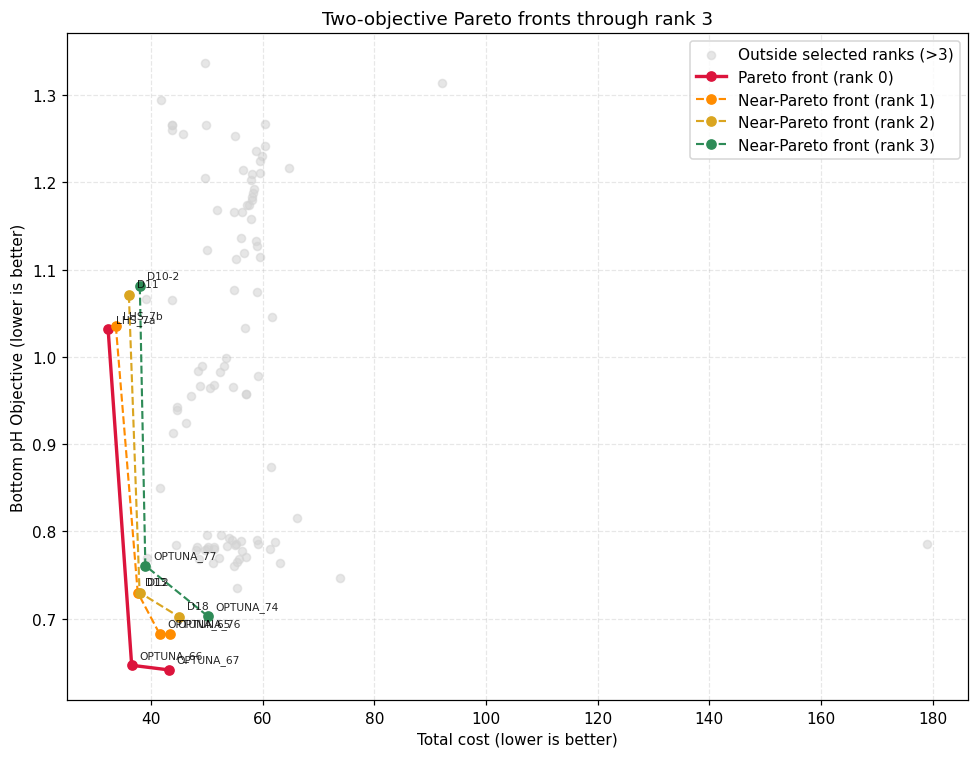

,Selection Role,Run Name,Cost,Bottom pH Objective,Bottom pH Cost Contribution,Non-bottom-pH Cost,Pareto Rank
0,Best holistic cost,LHS_7a,32.284426,1.031632,5.401483,26.882943,0
1,Best Bottom pH,OPTUNA_67,43.126533,0.641253,4.575913,38.550621,0
2,Balanced normalized compromise,OPTUNA_66,36.501727,0.646529,2.556314,33.945413,0


In [8]:
objective_relationship = DF_analysis[objective_columns].corr(method="spearman")
print("Spearman relationship between optimization objectives:")
display(objective_relationship)

fig, ax = plt.subplots(figsize=(9, 7))
pareto_rank = pd.to_numeric(DF_analysis["Pareto Rank"], errors="coerce")
outside_selected_fronts = pareto_rank.gt(NEAR_PARETO_RANK) | pareto_rank.isna()
ax.scatter(
    DF_analysis.loc[outside_selected_fronts, "Cost"],
    DF_analysis.loc[outside_selected_fronts, "Bottom pH Objective"],
    color="lightgray", alpha=0.55, s=28, label=f"Outside selected ranks (>{NEAR_PARETO_RANK})",
    zorder=1,
)

front_colors = ["crimson", "darkorange", "goldenrod", "seagreen", "royalblue", "mediumpurple"]
selected_fronts = []
for rank_number in range(NEAR_PARETO_RANK + 1):
    front = DF_analysis.loc[pareto_rank.eq(rank_number)].sort_values("Cost")
    if front.empty:
        continue
    selected_fronts.append(front)
    color = front_colors[rank_number % len(front_colors)]
    is_exact = rank_number == 0
    label = "Pareto front (rank 0)" if is_exact else f"Near-Pareto front (rank {rank_number})"
    ax.plot(
        front["Cost"], front["Bottom pH Objective"],
        color=color, marker="o", markersize=6,
        linestyle="-" if is_exact else "--",
        linewidth=2.2 if is_exact else 1.4, label=label, zorder=3,
    )

for front in selected_fronts:
    for _, row in front.iterrows():
        ax.annotate(
            row["Run Name"], (row["Cost"], row["Bottom pH Objective"]),
            xytext=(5, 5), textcoords="offset points", fontsize=7, alpha=0.85,
        )
ax.set(xlabel="Total cost (lower is better)", ylabel="Bottom pH Objective (lower is better)",
       title=f"Two-objective Pareto fronts through rank {NEAR_PARETO_RANK}")
ax.grid(linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

DF_representatives = cpu.select_representative_candidates(DF_analysis)
representative_columns = [column for column in [
    "Selection Role", "Run Name", "Cost", "Bottom pH Objective",
    "Bottom pH Cost Contribution", "Non-bottom-pH Cost", "Pareto Rank"
] if column in DF_representatives]
display(DF_representatives[representative_columns])

if "Non-bottom-pH Cost" not in DF_analysis:
    print("Non-bottom-pH diagnostic is unavailable in the legacy cache. Use a fresh rebuild when you need it.")


## 9. Review the parameter-prior input

`parameter_priors.csv` is the source of truth for your scientific decisions. The notebook never assumes that the reference notebook's active parameters are correct.

Decisions:

- `active`: include in this optimization.
- `fixed`: use the supplied fixed value.
- `reserve`: plausible, but not in this round.
- `exclude`: scientifically or operationally unavailable.
- `review`: no decision yet.

The supplied file begins conservatively with ordinary parameters marked `review` and unsupported CACO3 controls marked `exclude`.

**How to interpret the tables:** the first table is only an inventory of decisions by parameter type. If a `Parameters missing from the prior file` table appears, add those rows before relying on the later readiness checks. The larger table shows the maintained scientific inputs that will control later readiness checks and study construction; it is not a performance ranking. Blank bounds, choices, or fixed values are acceptable while a row remains under review, but must be completed when required by an `active` or `fixed` decision. In concise mode, the notebook reports how many rows still need review and displays the rows that already carry a decision.

In [9]:
prior_counts = DF_priors.groupby(["decision", "parameter_type"]).size().rename("Count").reset_index()
display(prior_counts)

candidate_inventory = list(dict.fromkeys([
    *cpu.OPTICS_PARAMETERS, *cpu.SEDIMENT_PARAMETERS,
    BIO_NL_TNU2_PARAMETER, BIO_ADVECTION_PARAMETER,
    *CPP_OPTION_PARAMETERS,
    *(name for specs in CPP_CONDITIONAL_FLOAT_VARIABLES.values() for names in specs.values() for name in names),
]))
coverage = cpu.prior_coverage(DF_priors, candidate_inventory)
missing_prior_rows = coverage.loc[~coverage["In prior file"]]
if not missing_prior_rows.empty:
    print("Parameters missing from the prior file:")
    display(missing_prior_rows)

review_columns = [
    "parameter", "parameter_type", "decision", "bottom_ph_relevance",
    "holistic_relevance", "confidence_in_current_value", "proposed_low",
    "proposed_high", "fixed_value", "parent_option", "scientific_rationale",
    "future_question", "notes",
]
if OUTPUT_DETAIL == "concise":
    decided = DF_priors.loc[~DF_priors["decision"].eq("review"), review_columns]
    print(f"Prior rows requiring scientific review: {int(DF_priors['decision'].eq('review').sum())}")
    if not decided.empty:
        display(decided)
else:
    display(DF_priors[review_columns])


,decision,parameter_type,Count
0,active,float,9
1,exclude,boolean,1
2,exclude,categorical,1
3,exclude,float,59
4,fixed,float,15
5,reserve,float,11


Prior rows requiring scientific review: 0


,parameter,parameter_type,decision,bottom_ph_relevance,holistic_relevance,confidence_in_current_value,proposed_low,proposed_high,fixed_value,parent_option,scientific_rationale,future_question,notes
0,reg1,float,active,unknown,unknown,unknown,0.10,0.2,NaN,NaN,Range chosen by top 14 Pareto-rank trials,What is this doing functionally? How do I expl...,No idea what will happen
1,reg2,float,active,unknown,unknown,unknown,0.08,0.1,NaN,NaN,Range chosen by top 14 Pareto-rank trials,What is this doing functionally? How do I expl...,No idea what will happen
2,gmaxs1,float,reserve,unknown,unknown,high,NaN,NaN,NaN,NaN,NaN,NaN,I feel like this is a parameter that could be ...
3,gmaxs2,float,reserve,unknown,unknown,high,NaN,NaN,NaN,NaN,NaN,NaN,I feel like this is a parameter that could be ...
4,rrb1,float,reserve,unknown,unknown,medium,0.20,0.4,NaN,NaN,NaN,Decide whether this parameter is scientificall...,Active in reference notebook; not automaticall...
5,rrb2,float,reserve,unknown,unknown,medium,0.20,0.4,NaN,NaN,NaN,Decide whether this parameter is scientificall...,Active in reference notebook; not automaticall...
6,rrg1,float,reserve,unknown,unknown,medium,0.10,0.3,NaN,NaN,NaN,Decide whether this parameter is scientificall...,Active in reference notebook; not automaticall...
7,rrg2,float,reserve,unknown,unknown,medium,0.10,0.3,NaN,NaN,NaN,Decide whether this parameter is scientificall...,Active in reference notebook; not automaticall...
8,beta1,float,active,unknown,unknown,unknown,0.30,0.6,NaN,NaN,Range based on literature review: https://docs...,NaN,Active in reference notebook; not automaticall...
9,beta2,float,active,unknown,unknown,unknown,0.30,0.6,NaN,NaN,Range based on literature review: https://docs...,NaN,Active in reference notebook; not automaticall...


## 10. Existing-evidence screening

This section asks what the archive can support before you choose active parameters. It does **not** equate correlation, model importance, or TPE preference with scientific truth.

Conditional children are excluded from general screening and should only be studied among runs where their parent option is enabled. Conditional parent options such as `CACO3` are included in the categorical table for descriptive comparison, even when they remain operationally excluded from candidate generation.

### How to read the Section 10 output

The three opening counts tell you how much can be screened: varied eligible numeric parameters, varied eligible categorical parameters, and strongly confounded numeric pairs. The tables that follow answer different questions; they should not be treated as one definitive parameter ranking.

#### Numeric-parameter table

Each row is one numeric parameter. The table is sorted by `strongest_association`, which is only a convenient screening order—not proof of importance. In concise mode, `N_SCREENING_PARAMETERS_TO_SHOW` controls the number of displayed rows without changing which parameters are eligible.

| Column | How to interpret it |
|---|---|
| `Available` | Number of analysis-ready runs containing a usable value |
| `Coverage` | Fraction of analysis-ready runs containing a usable value |
| `Unique Values` | Number of distinct values actually tested |
| `Tested Low`, `Tested High` | Full observed historical range; not automatically a recommended search range |
| `Promising Count` | Usable observations among runs inside the selected Pareto-rank boundary |
| `Promising 10%`, `Promising Median`, `Promising 90%` | Tentative distribution of values represented among promising runs; the 10%–90% interval contains their middle 80% |
| `Spearman: Cost` | Monotonic historical association with total cost |
| `Spearman: Bottom pH Objective` | Monotonic historical association with Bottom pH error |
| `strongest_association` | Larger absolute value of the two objective correlations; used to sort the display |

Both objectives are minimized. A **negative** Spearman value means larger parameter values tended to accompany lower (better) objective values. A **positive** value means larger parameter values tended to accompany higher (worse) objective values. A value near zero means there was no clear monotonic relationship in the archive. Correlation is not causation, especially when parameters changed together.

Use the promising percentiles as clues about a potentially useful region—not as automatic optimization bounds. A narrow interval may reflect sparse sampling, confounding, or repeated parameter sets rather than true convergence.

#### Categorical-parameter table

Each row is one category, such as an advection scheme or the enabled/disabled state of a conditional parent option. For example, the `CACO3=True` and `CACO3=False` rows compare the parent option only; they do not evaluate the CACO3-specific child parameters.

| Column | How to interpret it |
|---|---|
| `Runs` | Historical runs using this category |
| `Promising Runs` | Those runs that fall inside the selected Pareto-rank boundary |
| `P(Promising \| Category)` | Fraction of runs using this category that were promising |
| `95% Low`, `95% High` | Uncertainty interval for that probability |
| `Enrichment` | Category-specific promising rate divided by the overall promising rate |

An `Enrichment` near 1 means the category appears among promising runs about as often as expected. Above 1 means overrepresented; below 1 means underrepresented. Always consider `Runs` and the uncertainty interval—a striking result based on only a few runs is weak evidence.

#### Confounding table

This table lists pairs of numeric parameters that historically moved together strongly enough to exceed `STRONG_CONFOUNDING_THRESHOLD`. A correlation near +1 means they rose and fell together; near −1 means one rose as the other fell. Either pattern makes their individual effects difficult to separate. In concise and detailed output, `N_CONFOUNDING_PAIRS_TO_SHOW` controls how many pairs are displayed; `OUTPUT_DETAIL="debug"` displays all pairs.

A highly confounded parameter is not necessarily unimportant. It means the archive cannot confidently identify which member of the pair caused the observed outcome. A future focused round can help by varying one while holding the other fixed.

#### Practical decision checklist

For each parameter you might mark `active`:

1. Confirm adequate `Coverage` and more than a token number of `Unique Values`.
2. Check that `Promising Count` is large enough to support even a tentative pattern.
3. Treat the promising 10%–90% interval as a clue, not a hard boundary.
4. Examine associations with **both** objectives and remember that lower is better.
5. Look for the parameter in the confounding table.
6. Combine this evidence with scientific relevance and feasibility before editing `parameter_priors.csv`.

In [10]:
# Operationally excluded conditional parents are still useful descriptive categories.
# Their child parameters remain excluded from this general screening.
conditional_parent_parameters = set(CPP_CONDITIONAL_FLOAT_VARIABLES)
screening_priors = DF_priors.loc[
    ~DF_priors["decision"].eq("exclude")
    | DF_priors["parameter"].isin(conditional_parent_parameters)
].copy()
numeric_parameters = [
    parameter for parameter in screening_priors.loc[
        screening_priors["parameter_type"].isin(["float", "integer"]), "parameter"
    ] if parameter in DF_analysis and pd.to_numeric(DF_analysis[parameter], errors="coerce").nunique() > 1
]
categorical_parameters = [
    parameter for parameter in screening_priors.loc[
        screening_priors["parameter_type"].isin(["categorical", "boolean"]), "parameter"
    ] if parameter in DF_analysis and DF_analysis[parameter].nunique(dropna=True) > 1
]

DF_numeric_screening = cpu.numeric_screening_summary(
    DF_analysis, numeric_parameters, objective_columns
)
DF_categorical_screening = cpu.categorical_screening_summary(
    DF_analysis, categorical_parameters
)
DF_confounding = cpu.parameter_confounding(
    DF_analysis, numeric_parameters, threshold=STRONG_CONFOUNDING_THRESHOLD
)

print(f"Varied eligible numeric parameters: {len(numeric_parameters)}")
print(f"Varied eligible categorical parameters: {len(categorical_parameters)}")
print(f"Strongly confounded numeric pairs: {len(DF_confounding)}")

association_columns = [column for column in DF_numeric_screening if column.startswith("Spearman:")]
if association_columns:
    ranking = DF_numeric_screening.assign(
        strongest_association=DF_numeric_screening[association_columns].abs().max(axis=1)
    ).sort_values("strongest_association", ascending=False)
    display(
        ranking
        if OUTPUT_DETAIL != "concise"
        else ranking.head(N_SCREENING_PARAMETERS_TO_SHOW)
    )
if not DF_categorical_screening.empty:
    display(DF_categorical_screening)
if not DF_confounding.empty:
    display(
        DF_confounding
        if OUTPUT_DETAIL == "debug"
        else DF_confounding.head(N_CONFOUNDING_PAIRS_TO_SHOW)
    )


Varied eligible numeric parameters: 33
Varied eligible categorical parameters: 1
Strongly confounded numeric pairs: 123


,Parameter,Available,Coverage,Unique Values,Tested Low,Tested High,Promising Count,Promising 10%,Promising Median,Promising 90%,Spearman: Cost,Spearman: Bottom pH Objective,strongest_association
9,beta2,109,1.0,17,0.15000,2.000000,13,0.446035,0.544530,1.606997,0.031586,-0.699225,0.699225
8,beta1,109,1.0,17,0.50000,2.250000,13,0.819350,1.406325,2.100000,-0.164096,-0.695768,0.695768
21,bgamma6,109,1.0,14,0.00500,0.100000,13,0.010000,0.037491,0.094238,-0.202378,-0.670559,0.670559
10,akz1,109,1.0,10,0.25000,1.000000,13,0.500000,0.672197,1.000000,-0.055374,-0.664715,0.664715
11,akz2,109,1.0,11,0.50000,5.000000,13,0.500000,1.000000,1.857085,-0.070479,-0.643572,0.643572
17,bgamma3,109,1.0,8,0.10000,0.300000,13,0.100000,0.200000,0.240000,-0.200431,-0.557149,0.557149
12,amaxs1,109,1.0,7,0.03000,0.180000,13,0.100000,0.100000,0.100000,0.183816,-0.555433,0.555433
0,reg1,109,1.0,14,0.10000,0.400000,13,0.107616,0.200000,0.200000,-0.270097,-0.533667,0.533667
28,bUmax_nspc1,109,1.0,37,0.00274,0.027400,13,0.002740,0.003026,0.017555,0.261126,0.522664,0.522664
14,akno3s1,109,1.0,3,0.75000,1.500000,13,0.750000,0.750000,1.500000,0.285405,0.511533,0.511533


,Parameter,Category,Runs,Promising Runs,P(Promising | Category),95% Low,95% High,Enrichment
0,CACO3,False,103,13,0.126214,0.075264,0.204043,1.058252
1,CACO3,True,6,0,0.000000,0.000000,0.390343,0.000000


,Parameter 1,Parameter 2,Spearman Correlation,Absolute Correlation
0,rrb1,rrb2,0.999989,0.999989
1,rrg1,rrg2,0.999921,0.999921
2,gmaxs1,gmaxs2,0.999920,0.999920
3,rrb1,rrg2,0.987280,0.987280
4,rrb2,rrg2,0.987268,0.987268
5,rrb2,rrg1,0.987257,0.987257
6,rrb1,rrg1,0.987223,0.987223
7,wsp,nl_tnu2_tracer9,-0.981981,0.981981
8,akz1,akz2,0.946474,0.946474
9,beta1,akz2,0.944492,0.944492


## 11. Cross-validated nonlinear screening

A nonlinear importance estimate is useful only when the fitted model predicts held-out runs better than a mean-only baseline. Poor model validation means “the archive cannot answer this reliably,” not “the parameters do not matter.”

This calculation can take a few minutes. Set `RUN_NONLINEAR_SCREENING=False` in the control panel to skip it.

### How to interpret the performance table

Interpret an importance figure only after checking that objective's validation rows. `Held-out R2` above 0 means the model predicts unseen runs better than simply using the overall mean; higher is better. `Held-out MAE` is the typical absolute prediction error in that objective's own units; lower is better. Compare the random forest with the `Mean baseline`. If the random forest does not clearly improve on the baseline, the archive cannot support a reliable importance interpretation for that objective. `Runs` is the usable sample size and `Parameters` is the number of predictors supplied to the model.

### How to interpret the importance figure

Each bar measures how much held-out MAE increased when one parameter was randomly shuffled. A large positive bar means the fitted model repeatedly relied on that parameter for prediction. Near zero means shuffling made little difference. A negative bar means shuffling sometimes improved prediction and is evidence of instability or noise—not evidence of a beneficial negative effect. Error bars show variability across held-out folds and repeated shuffles; an interval that crosses zero is not stable evidence. Compare bar sizes only within the same objective because Cost and Bottom pH use different units.

This is **predictive importance, not causal importance**. Confounded parameters can divide importance, substitute for one another, or act as proxies for a family of runs. A low bar therefore does not prove scientific irrelevance, and a high bar does not prove that changing the parameter will improve the objective. Use this figure with Section 10's coverage, correlation, and confounding tables plus scientific judgment. The selected near-Pareto rank does not affect this model: Section 11 uses all analysis-ready runs and their continuous objective values.

,Objective,Model,Runs,Parameters,Held-out R2,Held-out MAE
0,Cost,Mixed-type Random Forest,109,34,-0.249865,6.795599
1,Cost,Mean baseline,109,0,-0.007872,7.546830
2,Bottom pH Objective,Mixed-type Random Forest,109,34,0.773039,0.062818
3,Bottom pH Objective,Mean baseline,109,0,-0.015135,0.176627


Cost: model did not beat a mean baseline reliably; importance is inconclusive.


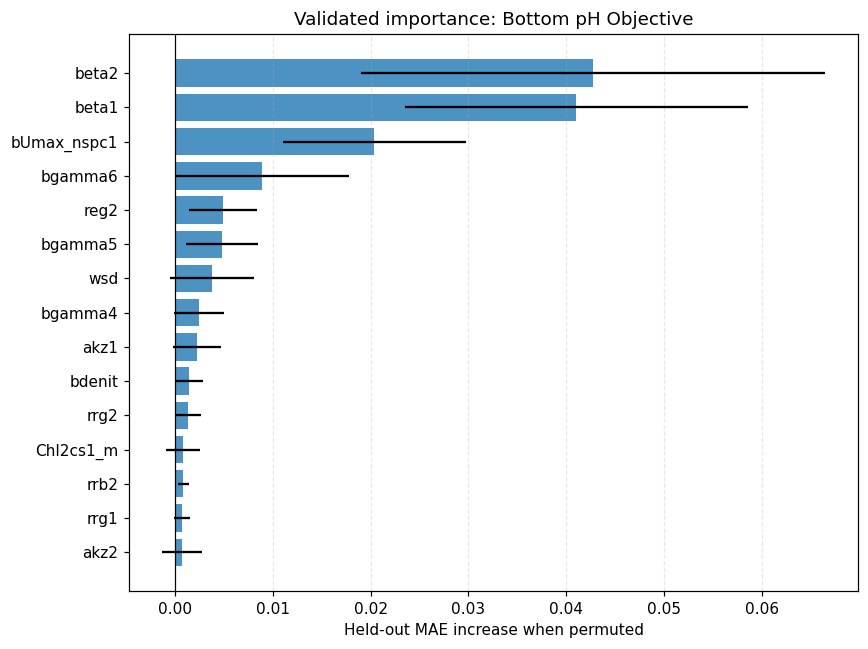

In [11]:
DF_model_performance = pd.DataFrame()
DF_nonlinear_importance = pd.DataFrame()
if RUN_NONLINEAR_SCREENING:
    DF_model_performance, DF_nonlinear_importance = cpu.cross_validated_mixed_importance(
        DF_analysis,
        numeric_parameters,
        categorical_parameters,
        objective_columns,
        random_state=RANDOM_SEED,
    )
    display(DF_model_performance)
    for objective in objective_columns:
        model_row = DF_model_performance.loc[
            (DF_model_performance["Objective"] == objective)
            & (DF_model_performance["Model"] == "Mixed-type Random Forest")
        ].iloc[0]
        if model_row["Held-out R2"] <= 0:
            print(f"{objective}: model did not beat a mean baseline reliably; importance is inconclusive.")
            continue
        plot_data = (
            DF_nonlinear_importance.loc[DF_nonlinear_importance["Objective"].eq(objective)]
            .nsmallest(15, "Rank").sort_values("Mean_Importance")
        )
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(plot_data["Parameter"], plot_data["Mean_Importance"],
                xerr=plot_data["SD_Importance"], color="tab:blue", alpha=0.8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set(xlabel="Held-out MAE increase when permuted", title=f"Validated importance: {objective}")
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()


## 12. What promising parameter values look like

For numeric parameters, the green distribution is the empirical distribution among Pareto and near-Pareto runs; gray is the rest. These are evidence distributions, not Bayesian posteriors.

The default display uses the strongest objective associations. `N_PARAMETER_DISTRIBUTIONS_TO_PLOT` controls how many numeric distributions appear without changing parameter eligibility.

### Numeric distribution plots

Green shows values from runs inside the selected Pareto-rank boundary; gray shows the remaining runs. Look for green values that repeatedly concentrate in a region that is not merely the most heavily sampled gray region. The vertical axis is **density**, not the number of runs, so a small promising group can form a tall bar. Histogram appearance also depends on bin placement. A narrow green shape is a tentative good region, not proof of convergence or a ready-made optimization bound.

### Categorical probability plots

Each bar is the observed fraction of runs in that category that were promising. The black interval shows uncertainty: wide or strongly overlapping intervals mean the categories are not clearly distinguishable with the current archive. Always pair this figure with the Section 10 `Runs`, `Promising Runs`, and `Enrichment` values. For a conditional parent such as `CACO3`, the plot compares enabled and disabled runs only; it says nothing about which child values work when enabled.

### Parallel-coordinate plot

Each line is one historical run and each vertical axis is one parameter. Values are independently rescaled from 0 (lowest tested value) to 1 (highest tested value), so heights cannot be compared as physical magnitudes across parameters. Repeated green paths or narrow green bands suggest a parameter-space pattern worth testing; extensive crossings or overlap with gray indicate multiple regimes, interactions, or weak separation. One green line is an anecdote, not a range estimate.

### Pairwise parameter plot

Off-diagonal panels show two parameters at a time: green points are promising runs and gray points are the rest. Green clustering can reveal combinations hidden by one-parameter summaries; diagonal panels show the overall one-parameter distribution. Check whether green clusters simply follow dense gray sampling, lie against tested boundaries, or contain only a few points. This view can suggest interactions but cannot establish which parameter caused the result.

### Focused parameter inspection — USER INPUT

The two separate blocks after the general figures are for questions you choose manually. The first compares selected parameter values run-by-run across Pareto ranks 0 through the chosen boundary. The second overlays the promising and other-run distributions for one numeric parameter using identical histogram bins. Edit only the clearly labeled parameter names; these displays do not change priors or Optuna.

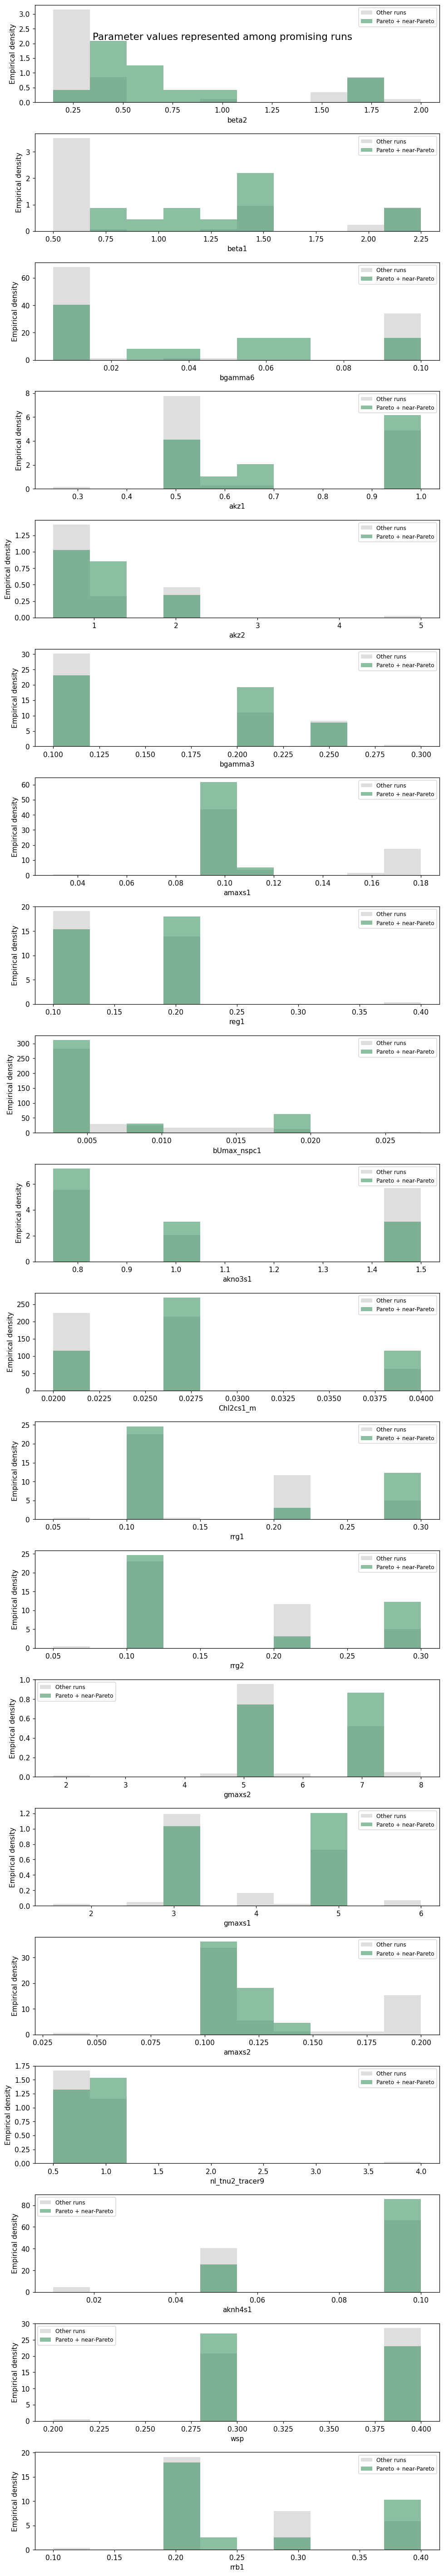

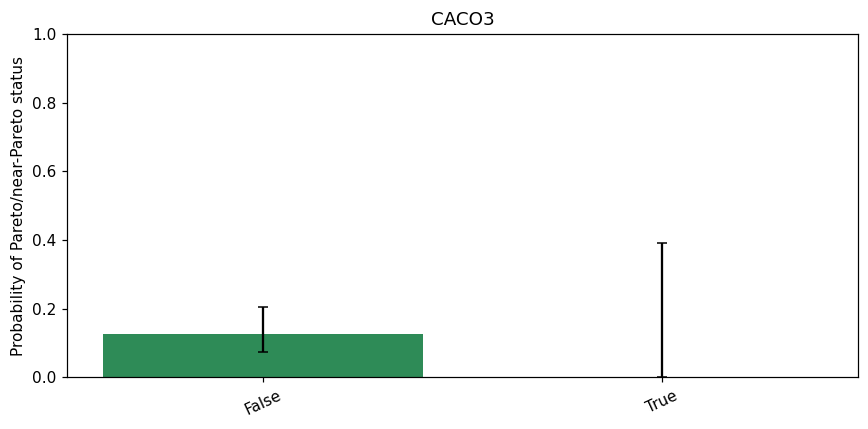

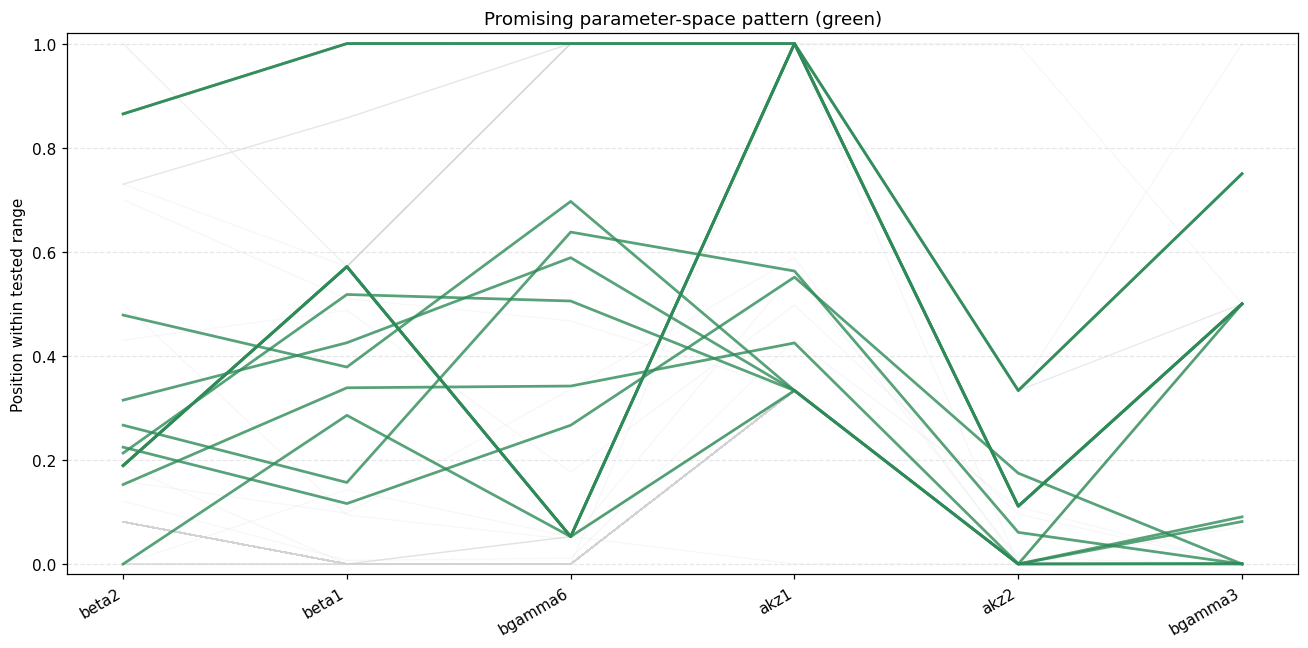

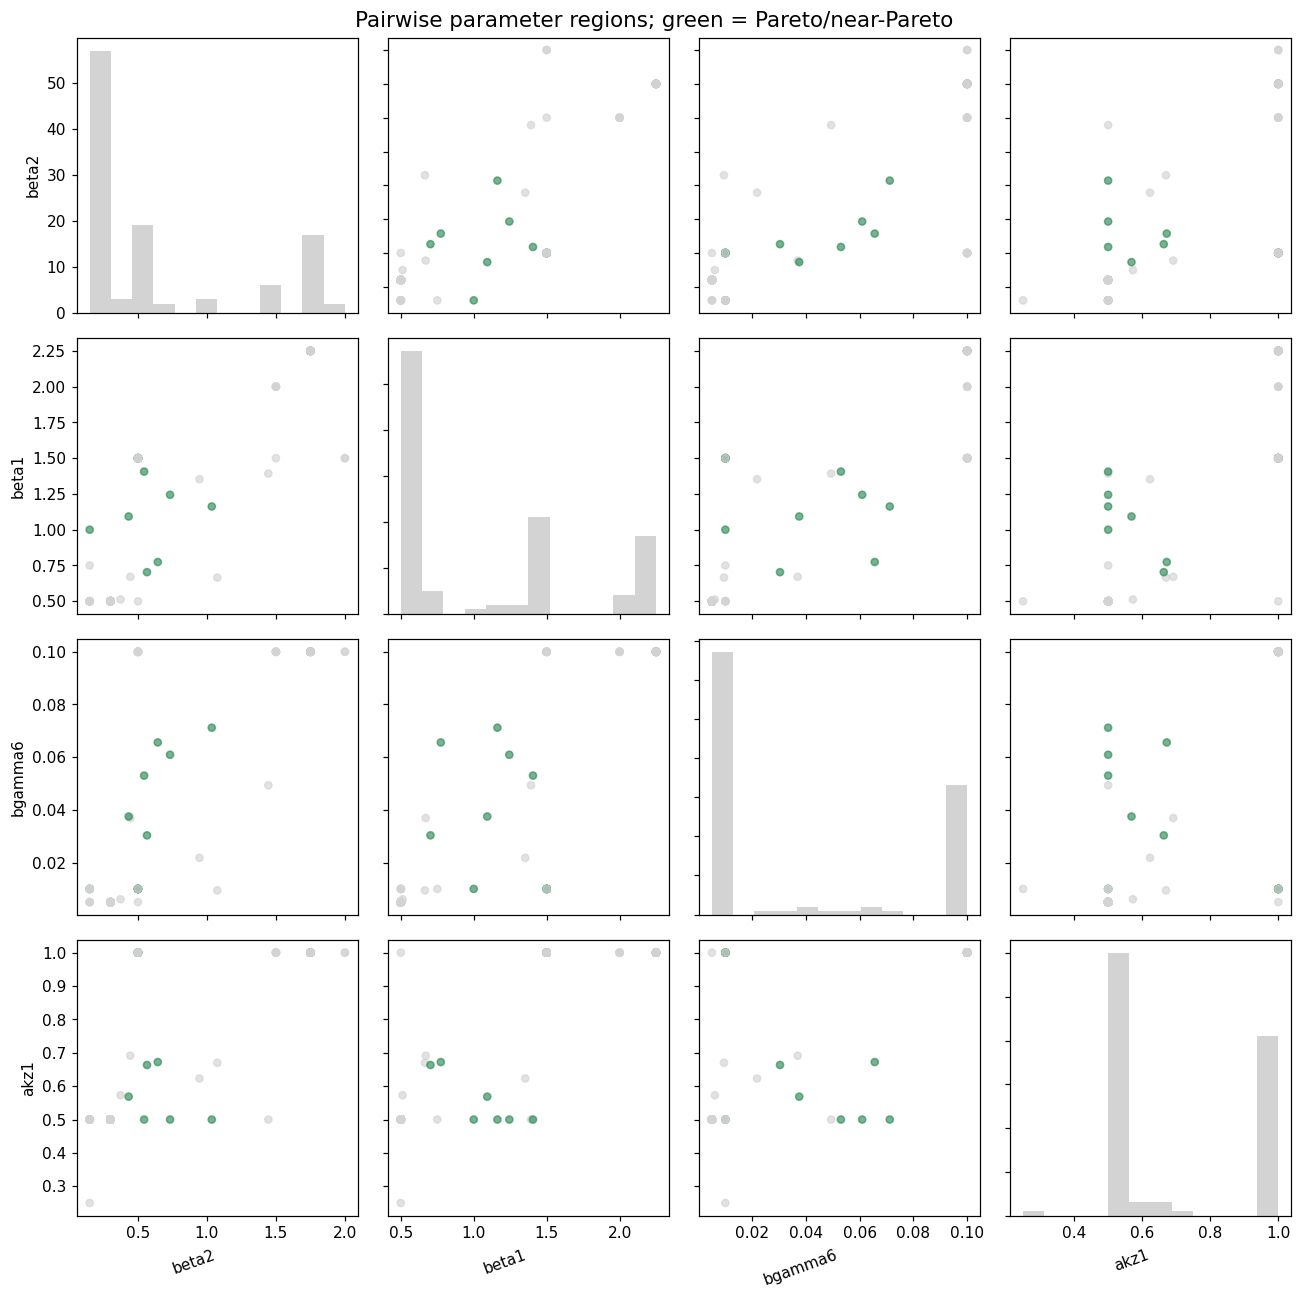

In [12]:
if not DF_numeric_screening.empty:
    association_columns = [column for column in DF_numeric_screening if column.startswith("Spearman:")]
    plot_order = DF_numeric_screening.assign(
        strongest=DF_numeric_screening[association_columns].abs().max(axis=1)
    ).sort_values("strongest", ascending=False)
    parameters_to_plot = (
        plot_order["Parameter"]
        .head(N_PARAMETER_DISTRIBUTIONS_TO_PLOT)
        .tolist()
    )
else:
    parameters_to_plot = []

if parameters_to_plot:
    fig, axes = plt.subplots(len(parameters_to_plot), 1, figsize=(9, 2.6 * len(parameters_to_plot)), squeeze=False)
    for ax, parameter in zip(axes.ravel(), parameters_to_plot):
        good = pd.to_numeric(DF_analysis.loc[DF_analysis["Near Pareto"], parameter], errors="coerce").dropna()
        other = pd.to_numeric(DF_analysis.loc[~DF_analysis["Near Pareto"], parameter], errors="coerce").dropna()
        usable = pd.to_numeric(DF_analysis[parameter], errors="coerce").dropna()
        bin_count = min(15, max(5, int(np.sqrt(len(usable)))))
        shared_bin_edges = np.histogram_bin_edges(usable, bins=bin_count)
        ax.hist(other, bins=shared_bin_edges, density=True, color="lightgray", alpha=0.75, label="Other runs")
        ax.hist(good, bins=shared_bin_edges, density=True, color="seagreen", alpha=0.55, label="Pareto + near-Pareto")
        ax.set(xlabel=parameter, ylabel="Empirical density")
        ax.legend(fontsize=8)
    fig.suptitle("Parameter values represented among promising runs", fontsize=14)
    plt.tight_layout()
    plt.show()

if not DF_categorical_screening.empty:
    for parameter, group in DF_categorical_screening.groupby("Parameter"):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(group["Category"].astype(str), group["P(Promising | Category)"], color="seagreen")
        ax.errorbar(
            group["Category"].astype(str), group["P(Promising | Category)"],
            yerr=[group["P(Promising | Category)"] - group["95% Low"], group["95% High"] - group["P(Promising | Category)"]],
            fmt="none", ecolor="black", capsize=3,
        )
        ax.set(ylim=(0, 1), ylabel="Probability of Pareto/near-Pareto status", title=parameter)
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()
        plt.show()

# A compact map of the promising region across several parameters at once.
parallel_parameters = parameters_to_plot[:6]
if len(parallel_parameters) >= 2:
    parallel = DF_analysis[parallel_parameters].apply(pd.to_numeric, errors="coerce")
    normalized = parallel.copy()
    for parameter in parallel_parameters:
        low, high = parallel[parameter].min(), parallel[parameter].max()
        normalized[parameter] = (parallel[parameter] - low) / (high - low) if high > low else 0.5
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(parallel_parameters))
    for index, row in normalized.loc[~DF_analysis["Near Pareto"]].iterrows():
        ax.plot(x, row, color="lightgray", alpha=0.18, linewidth=0.8)
    for index, row in normalized.loc[DF_analysis["Near Pareto"]].iterrows():
        ax.plot(x, row, color="seagreen", alpha=0.8, linewidth=1.8)
    ax.set_xticks(x, parallel_parameters, rotation=30, ha="right")
    ax.set(ylabel="Position within tested range", ylim=(-0.02, 1.02),
           title="Promising parameter-space pattern (green)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Pairwise views help reveal combinations hidden by one-parameter distributions.
pair_parameters = parameters_to_plot[:4]
if len(pair_parameters) >= 2:
    size = len(pair_parameters)
    fig, axes = plt.subplots(size, size, figsize=(3 * size, 3 * size))
    for row_index, y_parameter in enumerate(pair_parameters):
        for column_index, x_parameter in enumerate(pair_parameters):
            ax = axes[row_index, column_index]
            if row_index == column_index:
                ax.hist(pd.to_numeric(DF_analysis[x_parameter], errors="coerce").dropna(), bins=12, color="lightgray")
            else:
                ax.scatter(DF_analysis[x_parameter], DF_analysis[y_parameter], c=np.where(DF_analysis["Near Pareto"], "seagreen", "lightgray"), alpha=0.65, s=22)
            if row_index == size - 1:
                ax.set_xlabel(x_parameter, rotation=20, ha="right")
            else:
                ax.set_xticklabels([])
            if column_index == 0:
                ax.set_ylabel(y_parameter)
            else:
                ax.set_yticklabels([])
    fig.suptitle("Pairwise parameter regions; green = Pareto/near-Pareto", fontsize=14)
    plt.tight_layout()
    plt.show()


In [13]:
# ============================================================
# USER INPUT: compare selected parameters across promising runs
# ============================================================
PARAMETERS_TO_COMPARE = [
    "bgamma7",
    "bgamma6",
    "bnit",
    "bw",
]
FOCUSED_TABLE_MAX_PARETO_RANK = NEAR_PARETO_RANK

missing_focused_parameters = [
    parameter
    for parameter in PARAMETERS_TO_COMPARE
    if parameter not in DF_analysis.columns
]
if missing_focused_parameters:
    raise ValueError(
        f"Focused-table parameters are missing: {missing_focused_parameters}"
    )

focused_table_mask = DF_analysis["Pareto Rank"].le(
    FOCUSED_TABLE_MAX_PARETO_RANK
)
DF_focused_parameter_table = (
    DF_analysis.loc[
        focused_table_mask,
        [
            "Run Name",
            "Cost",
            "Bottom pH Objective",
            "Pareto Rank",
            *PARAMETERS_TO_COMPARE,
        ],
    ]
    .sort_values(["Pareto Rank", "Cost", "Bottom pH Objective"])
    .reset_index(drop=True)
)

print(
    f"Focused comparison: {len(DF_focused_parameter_table)} runs "
    f"in Pareto ranks 0–{FOCUSED_TABLE_MAX_PARETO_RANK}"
)
display(DF_focused_parameter_table)

Focused comparison: 13 runs in Pareto ranks 0–3


,Run Name,Cost,Bottom pH Objective,Pareto Rank,bgamma7,bgamma6,bnit,bw
0,LHS_7a,32.284426,1.031632,0,0.257620,0.100000,0.150000,0.25
1,OPTUNA_66,36.501727,0.646529,0,0.282966,0.037491,0.162066,0.25
2,OPTUNA_67,43.126533,0.641253,0,0.279042,0.030332,0.178547,0.25
3,LHS_7b,33.664324,1.035572,1,0.257620,0.100000,0.150000,0.25
4,D13,37.584764,0.729879,1,0.250000,0.010000,0.150000,0.25
5,OPTUNA_65,41.502940,0.682559,1,0.272892,0.065595,0.158613,0.25
6,OPTUNA_76,43.324951,0.682148,1,0.257631,0.060918,0.157491,0.25
7,D11,36.003680,1.071017,2,0.250000,0.010000,0.150000,0.25
8,D12,37.916438,0.729938,2,0.250000,0.010000,0.150000,0.25
9,D18,45.057419,0.701831,2,0.250000,0.010000,0.150000,0.25


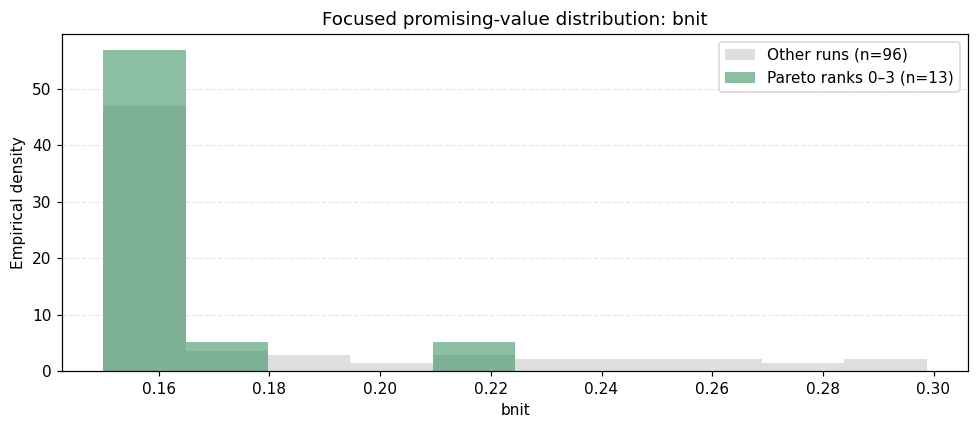

In [14]:
# ============================================================
# USER INPUT: inspect one numeric parameter in its own figure
# ============================================================
PARAMETER_TO_INSPECT = "bnit"
FOCUSED_PLOT_MAX_PARETO_RANK = NEAR_PARETO_RANK

if PARAMETER_TO_INSPECT not in DF_analysis.columns:
    raise ValueError(
        f"{PARAMETER_TO_INSPECT!r} is not present in the analysis archive."
    )

all_values = pd.to_numeric(
    DF_analysis[PARAMETER_TO_INSPECT], errors="coerce"
)
usable_values = all_values.dropna()
if usable_values.empty:
    raise ValueError(
        f"{PARAMETER_TO_INSPECT!r} has no usable numeric values."
    )

focused_plot_mask = DF_analysis["Pareto Rank"].le(
    FOCUSED_PLOT_MAX_PARETO_RANK
)
promising_values = all_values.loc[focused_plot_mask].dropna()
other_values = all_values.loc[~focused_plot_mask].dropna()
bin_count = min(15, max(5, int(np.sqrt(len(usable_values)))))
shared_bin_edges = np.histogram_bin_edges(usable_values, bins=bin_count)

fig, ax = plt.subplots(figsize=(9, 4))
if not other_values.empty:
    ax.hist(
        other_values, bins=shared_bin_edges, density=True,
        color="lightgray", alpha=0.75,
        label=f"Other runs (n={len(other_values)})",
    )
if not promising_values.empty:
    ax.hist(
        promising_values, bins=shared_bin_edges, density=True,
        color="seagreen", alpha=0.55,
        label=(
            f"Pareto ranks 0–{FOCUSED_PLOT_MAX_PARETO_RANK} "
            f"(n={len(promising_values)})"
        ),
    )

ax.set(
    xlabel=PARAMETER_TO_INSPECT,
    ylabel="Empirical density",
    title=f"Focused promising-value distribution: {PARAMETER_TO_INSPECT}",
)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Readiness and trial-budget checkpoint

This is the required scientific pause. The notebook will not silently inherit an active list.

Before preparing the study:

- Resolve every parameter still marked `review` that you intend to use.
- Keep the focused active set near 5–8 numeric parameters when the run budget is small.
- Treat high confounding, weak category counts, and poor objective prediction as uncertainty.
- Keep plausible but lower-priority parameters in `reserve`, not permanently discarded.

### How to interpret the readiness tables

The first table counts the final `Readiness` labels; the second counts the underlying `Empirical Evidence` labels. These labels are conservative triage rules, not statistical verdicts. `Needs scientific decision` means the prior file still says `review`. `Needs exploration` usually means too few distinct values, too few promising observations, or sparse categories. `Optimize cautiously` means the parameter has usable coverage but is strongly confounded. `Ready to optimize` means it passes the notebook's basic coverage checks—not that it is proven important. `Probably safe to fix` applies only to the current proposed round and can be revisited.

The named parameter table below combines your maintained decision with empirical coverage and confounding. It shows every non-excluded parameter, sorted into explicit action groups, with a short `Guidance` statement. `Empirical Evidence` describes what the archive can support; `Decision` remains your scientific choice. A disagreement between them is a prompt to document your rationale, not an automatic error. Excluded parameters remain summarized by count in concise mode and are shown individually in detailed/debug mode.

**Important:** `Probably safe to fix` means a parameter you already marked `fixed` has adequate variation, at least three promising observations, and no confounding pair above the configured threshold. It does not prove that the particular `fixed_value` is optimal. `Fix cautiously` means the archive cannot independently support the fixed decision because the parameter is strongly confounded. `Needs exploration` indicates sparse numeric or categorical evidence; `Optimize cautiously` identifies an active, strongly confounded parameter; `Insufficient evidence` means the archive cannot currently assess the parameter.

### How to interpret the budget table

`Categorical burden` counts the extra choices beyond one for each active categorical parameter. `Effective dimensions` adds that burden to the active numeric count as a deliberately simple complexity heuristic. `Limited`, `Focused`, and `Supported` compare that heuristic with `TRIAL_BUDGET`; they do not guarantee convergence. The budget table counts only rows currently marked `active`, so an appealing assessment is meaningless if important decisions are still left as `review`. If the rating is `Limited`, narrow the active scientific question before merely increasing confidence in the output.

In [15]:
DF_readiness = cpu.readiness_summary(
    DF_priors, DF_numeric_screening, DF_categorical_screening, DF_confounding
)
readiness_guidance = {
    "Probably safe to fix": "Keeping this fixed is defensible for this round; verify the chosen fixed value scientifically.",
    "Fix cautiously": "The fixed choice is not independently validated because this parameter is strongly confounded.",
    "Ready to optimize": "Archive coverage is adequate for inclusion; scientific relevance and budget still govern.",
    "Held in reserve": "Leave out of this focused round unless the scientific scope expands.",
    "Optimize cautiously": "Strongly confounded; vary deliberately or separate it from correlated parameters.",
    "Needs exploration": "Existing values or categories are too sparse for a stable conclusion.",
    "Insufficient evidence": "The archive cannot assess this parameter; use scientific knowledge or targeted runs.",
    "Needs scientific decision": "Complete the prior decision before study preparation.",
    "Operationally or scientifically excluded": "No action in the current workflow.",
}
readiness_order = [
    "Probably safe to fix",
    "Fix cautiously",
    "Ready to optimize",
    "Held in reserve",
    "Optimize cautiously",
    "Needs exploration",
    "Insufficient evidence",
    "Needs scientific decision",
    "Operationally or scientifically excluded",
]
DF_readiness["Guidance"] = DF_readiness["Readiness"].map(readiness_guidance)
DF_readiness["Readiness Sort"] = pd.Categorical(
    DF_readiness["Readiness"], categories=readiness_order, ordered=True
)
readiness_overview = (
    DF_readiness.groupby("Readiness Sort", observed=True, sort=True)
    .agg(
        Count=("Parameter", "size"),
        Parameters=("Parameter", lambda values: ", ".join(sorted(values))),
    )
    .reset_index()
    .rename(columns={"Readiness Sort": "Readiness"})
)
excluded_label = "Operationally or scientifically excluded"
if OUTPUT_DETAIL == "concise":
    readiness_overview.loc[
        readiness_overview["Readiness"].eq(excluded_label), "Parameters"
    ] = "Hidden in concise mode; use detailed/debug to list them"
display(readiness_overview)
evidence_counts = DF_readiness["Empirical Evidence"].value_counts().rename_axis("Empirical Evidence").reset_index(name="Count")
display(evidence_counts)
readiness_review_columns = [
    "Parameter", "Decision", "Readiness", "Empirical Evidence",
    "Confounded", "Guidance",
]
readiness_review = DF_readiness.sort_values(
    ["Readiness Sort", "Parameter"]
)
if OUTPUT_DETAIL == "concise":
    readiness_review = readiness_review.loc[
        ~readiness_review["Readiness"].eq(excluded_label)
    ]
display(readiness_review[readiness_review_columns].reset_index(drop=True))

active_prior_rows = DF_priors.loc[DF_priors["decision"].eq("active")]
active_numeric_rows = active_prior_rows.loc[active_prior_rows["parameter_type"].isin(["float", "integer"])]
active_categorical_rows = active_prior_rows.loc[active_prior_rows["parameter_type"].isin(["categorical", "boolean"])]
category_counts = [len(str(value).split("|")) for value in active_categorical_rows["allowed_choices"]]
budget = cpu.budget_assessment(len(active_numeric_rows), category_counts, TRIAL_BUDGET)
display(pd.DataFrame([budget]).T.rename(columns={0: "Value"}))

print("Proposed active numeric parameters:", active_numeric_rows["parameter"].tolist())
print("Proposed active categorical parameters:", active_categorical_rows["parameter"].tolist())
if DF_priors["decision"].eq("review").any():
    print(f"Parameters still awaiting a decision: {int(DF_priors['decision'].eq('review').sum())}")


# Durable audit tables are written separately from the validated source cache.
if SAVE_AUDIT_OUTPUTS:
    audit_tables = {
        "mo_bio_analysis_archive.csv": DF_analysis,
        "mo_bio_pareto_and_near_pareto_runs.csv": DF_analysis.loc[DF_analysis["Near Pareto"]],
        "mo_bio_representative_runs.csv": DF_representatives,
        "mo_bio_numeric_screening.csv": DF_numeric_screening,
        "mo_bio_categorical_screening.csv": DF_categorical_screening,
        "mo_bio_numeric_confounding.csv": DF_confounding,
        "mo_bio_model_performance.csv": DF_model_performance,
        "mo_bio_nonlinear_importance.csv": DF_nonlinear_importance,
        "mo_bio_parameter_readiness.csv": DF_readiness.drop(columns=["Readiness Sort"]),
        "mo_bio_focused_parameter_table.csv": DF_focused_parameter_table,
    }
    for filename, table in audit_tables.items():
        cpu.atomic_write_csv(table, OUTPUT_PATHS.audit_directory / filename, index=False)
    print(f"Audit tables: {OUTPUT_PATHS.audit_directory}")

,Readiness,Count,Parameters
0,Probably safe to fix,7,"amaxs1, bUmax_nspc0, bUmax_nspc1, bdenit, bgam..."
1,Fix cautiously,3,"Chl2cs2_m, amaxs2, bgamma3"
2,Ready to optimize,2,"bgamma5, reg2"
3,Held in reserve,7,"akno3s2, gmaxs1, gmaxs2, rrb1, rrb2, rrg1, rrg2"
4,Optimize cautiously,7,"akz1, akz2, beta1, beta2, bgamma6, reg1, wsd"
5,Needs exploration,7,"Chl2cs1_m, aknh4s1, akno3s1, bao2, bgamma5s, n..."
6,Insufficient evidence,2,"aknh4s2, bdo_c"
7,Operationally or scientifically excluded,61,Hidden in concise mode; use detailed/debug to ...


,Empirical Evidence,Count
0,Insufficient archive evidence,61
1,Strongly confounded,17
2,Supported empirical coverage,9
3,Sparse numeric coverage,7
4,Sparse categorical coverage,2


,Parameter,Decision,Readiness,Empirical Evidence,Confounded,Guidance
0,amaxs1,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
1,bUmax_nspc0,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
2,bUmax_nspc1,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
3,bdenit,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
4,bgamma4,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
5,bgamma7,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
6,bnit,fixed,Probably safe to fix,Supported empirical coverage,False,Keeping this fixed is defensible for this roun...
7,Chl2cs2_m,fixed,Fix cautiously,Strongly confounded,True,The fixed choice is not independently validate...
8,amaxs2,fixed,Fix cautiously,Strongly confounded,True,The fixed choice is not independently validate...
9,bgamma3,fixed,Fix cautiously,Strongly confounded,True,The fixed choice is not independently validate...


,Value
Active numeric parameters,9
Categorical burden,0
Effective dimensions (heuristic),9
Trial budget,30
Assessment,Focused
Interpretation,Reasonable for focused optimization; interacti...


Proposed active numeric parameters: ['reg1', 'reg2', 'beta1', 'beta2', 'akz1', 'akz2', 'bgamma5', 'bgamma6', 'wsd']
Proposed active categorical parameters: []
Audit tables: /Users/akbaskind/Desktop/Optimization/MO-BIO/audit


## 14. Prepare the new study

This section does nothing in review mode. In `prepare_study` mode it creates or loads the separate two-objective database, verifies objective/search-space fingerprints, and imports eligible historical runs.

**Database write:** preparing a study is permanent. If objectives, bounds, active parameters, or categorical choices change later, use a new study identity.

**Two different numeric ranges are intentional:** the historical-support range is wide enough to represent valid values already tested in the archive. The candidate range is the literature-supported `proposed_low`–`proposed_high` interval from `parameter_priors.csv`. Historical values outside the candidate range may teach TPE, but every new recommendation remains hard-limited to the candidate range. Values are never clipped or rewritten. Categorical choices remain strict.

**How to interpret the range table:** `Historical Values Outside Candidate Bounds` counts usable archive evidence outside the future recommendation range. This is expected under `observed_support`; it is not a data-quality warning. A large count means historical outcomes may still influence preference near a candidate boundary, so inspect boundary behavior cautiously.

**How to interpret the import-status table:** `added` means the historical run became a completed two-objective trial; `already present` means duplicate import was safely avoided. `missing active parameter`, `missing objective`, and `unknown category` explain exclusions. `outside configured bounds` applies only if the conservative `candidate_bounds` policy is selected. Imported historical trials initialize TPE; they are not evidence of choices made sequentially by this new sampler.

In [16]:
study = None
DF_historical_import = pd.DataFrame()
DF_historical_numeric_support = pd.DataFrame()

numeric_bounds = {
    row.parameter: (float(row.proposed_low), float(row.proposed_high))
    for row in active_numeric_rows.itertuples(index=False)
}
categorical_choices = {
    row.parameter: cpu.parse_prior_choices(row)
    for row in active_categorical_rows.itertuples(index=False)
}
DF_historical_numeric_support = cpu.historical_numeric_support_table(DF_analysis, numeric_bounds)
sampler_settings = {"seed": RANDOM_SEED, "n_startup_trials": 10, "multivariate": True}
fingerprint = cpu.search_space_fingerprint(
    objective_columns, numeric_bounds, categorical_choices, sampler_settings=sampler_settings
)

study_modes = {"prepare_study", "generate_candidates", "register_results", "write_inputs"}
if RUN_MODE in study_modes:
    if not numeric_bounds and not categorical_choices:
        raise ValueError("No active parameters. Edit parameter_priors.csv before preparing the study.")
    study = cpu.create_or_load_multiobjective_study(
        study_name=STUDY_NAME,
        storage=STORAGE,
        objective_version=OBJECTIVE_VERSION,
        fingerprint=fingerprint,
        seed=RANDOM_SEED,
        n_startup_trials=10,
        multivariate=True,
        historical_numeric_import_policy=HISTORICAL_NUMERIC_IMPORT_POLICY,
    )
    print(f"Study loaded: {study.study_name}; trials={len(study.trials)}")

if RUN_MODE == "prepare_study":
    DF_historical_import = cpu.import_historical_multiobjective_trials(
        study,
        DF_analysis,
        numeric_bounds=numeric_bounds,
        categorical_choices=categorical_choices,
        objective_columns=objective_columns,
        objective_version=OBJECTIVE_VERSION,
        numeric_import_policy=HISTORICAL_NUMERIC_IMPORT_POLICY,
    )
    study.set_user_attr("Historical Import Completed", True)
    study.set_user_attr("Historical Import Completed UTC", cpu.utc_now_text())
    display(DF_historical_numeric_support)
    display(DF_historical_import["Import Status"].value_counts().rename("Count").to_frame())


if not DF_historical_import.empty:
    cpu.atomic_write_csv(
        DF_historical_import,
        OUTPUT_PATHS.provenance_directory / "mo_bio_historical_import.csv",
        index=False,
    )
if not DF_historical_numeric_support.empty and RUN_MODE == "prepare_study":
    cpu.atomic_write_csv(
        DF_historical_numeric_support,
        OUTPUT_PATHS.provenance_directory / "mo_bio_historical_numeric_support.csv",
        index=False,
    )

/Users/akbaskind/Documents/Python Scripts/ROMS/ROMS-COSiNE-NB_Tuning/candidate_parameter_utils.py:1899: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-09-20 15:16:16,295] Using an existing study with name 'model_calibration_bio_cost_bottom_ph' instead of creating a new one.


Study loaded: model_calibration_bio_cost_bottom_ph; trials=113


## 15. Register completed model runs

In `register_results` mode this completes eligible RUNNING trials with both objective values. In every other mode it is inactive. Use a fresh data read first when new model outputs have arrived.

**How to interpret the table:** `completed` means both objectives were found and permanently recorded in the study. `results unavailable` means no matching archive row was found; `objectives incomplete` means a row exists but cannot yet supply both finite objectives. Verify the study run name, actual run name, and trial number before correcting a run-map problem. Do not manufacture objective values merely to clear a RUNNING trial.

In [17]:
DF_registration = pd.DataFrame()
if RUN_MODE == "register_results":
    DF_registration = cpu.synchronize_running_trials(
        study, DF_analysis, objective_columns=objective_columns,
        run_map=None, study_name=STUDY_NAME, commit=True
    )
    if DF_registration.empty:
        print("No RUNNING trials were found.")
    else:
        display(DF_registration)

## 16. Generate a candidate batch

In `generate_candidates` mode TPE creates RUNNING trials only when no previous trials remain RUNNING. A complete, cumulative candidate summary is saved under `MO-BIO/candidates/`. It includes study provenance, all active proposals, and fixed/baseline values used to resolve generated inputs.

**How to interpret the candidate table:** each row is a proposed experiment, not a predicted winner or a ranking. `Run Name` and `Trial Number` are durable identifiers that must remain attached to the resulting model output; the remaining columns are the values to apply. TPE intentionally balances currently promising regions with uncertainty, so unusual-looking candidates are not automatically errors. Review every value for physical and operational feasibility before writing or launching model inputs.

MO-BIO run names are official model run names; no separate MO-BIO run map is used. Pair each official name with its PHYS candidate in the PHYS run map.

In [18]:
DF_candidates = pd.DataFrame()
if RUN_MODE == "generate_candidates":
    if not study.user_attrs.get("Historical Import Completed", False):
        raise ValueError("Historical initialization is incomplete. Run prepare_study first.")
    proposed_candidates = cpu.ask_candidate_trials(
        study,
        numeric_bounds=numeric_bounds,
        categorical_choices=categorical_choices,
        count=N_CANDIDATES,
        run_name_prefix="OPTUNA_BIO_MO_",
        objective_version=OBJECTIVE_VERSION,
    )

    baseline_matches = DF_analysis.loc[DF_analysis["Run Name"].eq(BASELINE_RUN_NAME)]
    if len(baseline_matches) != 1:
        raise ValueError(
            f"Expected exactly one baseline run {BASELINE_RUN_NAME!r}; "
            f"found {len(baseline_matches)}"
        )
    baseline = baseline_matches.iloc[0]
    template_parameters = [
        *cpu.OPTICS_PARAMETERS,
        *cpu.SEDIMENT_PARAMETERS,
        BIO_NL_TNU2_PARAMETER,
        BIO_ADVECTION_PARAMETER,
    ]
    fixed_values = {}
    for parameter in template_parameters:
        if (
            parameter not in baseline.index
            or pd.isna(baseline[parameter])
            or parameter in proposed_candidates.columns
        ):
            continue
        fixed_values[parameter] = (
            str(baseline[parameter])
            if parameter == BIO_ADVECTION_PARAMETER
            else float(baseline[parameter])
        )
    for row in DF_priors.loc[DF_priors["decision"].eq("fixed")].itertuples(index=False):
        fixed_values[row.parameter] = cpu.parse_prior_fixed_value(row)

    DF_candidates = cpu.build_complete_candidate_summary(
        proposed_candidates,
        study_name=STUDY_NAME,
        objective_version=OBJECTIVE_VERSION,
        search_space_fingerprint=fingerprint,
        parameter_priors_file=PARAMETER_PRIORS_FILE,
        baseline_run_name=BASELINE_RUN_NAME,
        sampler_name=type(study.sampler).__name__,
        fixed_values=fixed_values,
        priors=DF_priors,
    )
    DF_candidate_history = cpu.append_candidate_summary(
        DF_candidates, OUTPUT_PATHS.candidate_summary_file
    )
    display(DF_candidates)
    print(f"Complete candidate summary: {OUTPUT_PATHS.candidate_summary_file}")

## 17. What multi-objective TPE is learning

This section is available after the new study exists. It samples Optuna's actual promising and less-promising Parzen models.

Because Optuna does not expose these models publicly, exact reconstruction is pinned to Optuna 4.9.x. If compatibility fails, the empirical plots above remain valid. Historical initialization is not mislabeled as sequential TPE learning; genuine evolution begins with trials whose origin is `Multi-objective TPE`.

### How to interpret the provenance and metadata tables

The provenance count separates historical initialization, previous-optimizer runs, and genuine proposals from this multi-objective TPE study. Use it to judge how much of the displayed preference reflects old evidence versus sequential learning. The metadata table reports which completed trials Optuna placed in its promising and less-promising groups for this reconstruction; those groups are internal sampler modeling sets and need not match the notebook's Pareto-rank evidence group.

### How to interpret numeric TPE distributions

Green `l(x)` is the sampler's modeled density for promising trials and gray `g(x)` is its modeled density for less-promising trials. TPE favors regions where green is large **relative to gray**; a tall green bar alone is not enough if gray is equally tall. Strong separation suggests a learned preference, broad overlap suggests uncertainty or continued exploration, and multiple peaks suggest more than one plausible regime. The dotted lines mark the hard candidate bounds: TPE may learn from historical values beyond them, but it cannot recommend beyond them. Accumulation at a candidate boundary can mean a real edge preference or that useful historical evidence lies outside the allowed range; it does not automatically justify expanding a literature-supported bound. These are sampler beliefs, not Bayesian posteriors about scientific truth.

### How to interpret categorical TPE tables

`Promising l(x)` and `Less-promising g(x)` are modeled category probabilities. A `Preference ratio l/g` above 1 favors that category relative to the less-promising model; below 1 disfavors it. Very large or missing ratios can occur when the gray probability is near zero and should be treated cautiously, especially with few genuine TPE trials.

,Trials
Origin,
Historical archive,98
Previous optimizer,11
Multi-objective TPE,4


,Value
Optuna version,4.9.0
Usable trials,109
Promising trial count,11
Less-promising trial count,98
Promising trial numbers,"[13, 14, 15, 18, 52, 53, 102, 103, 104, 107, 108]"
Less-promising trial numbers,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16,..."
Private API,True


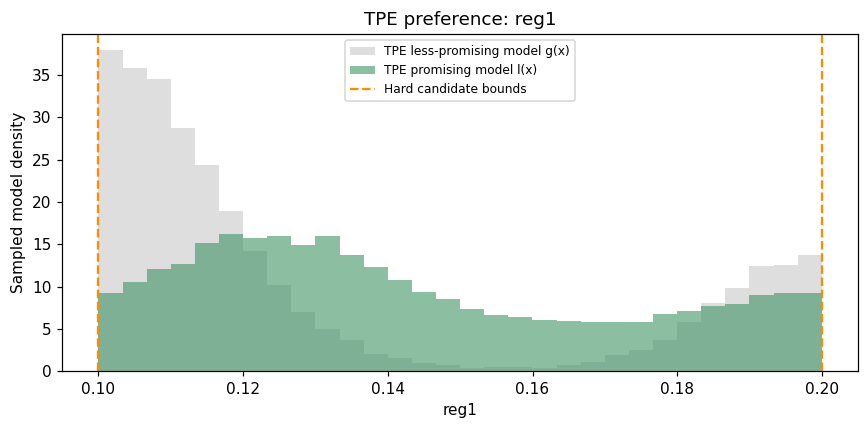

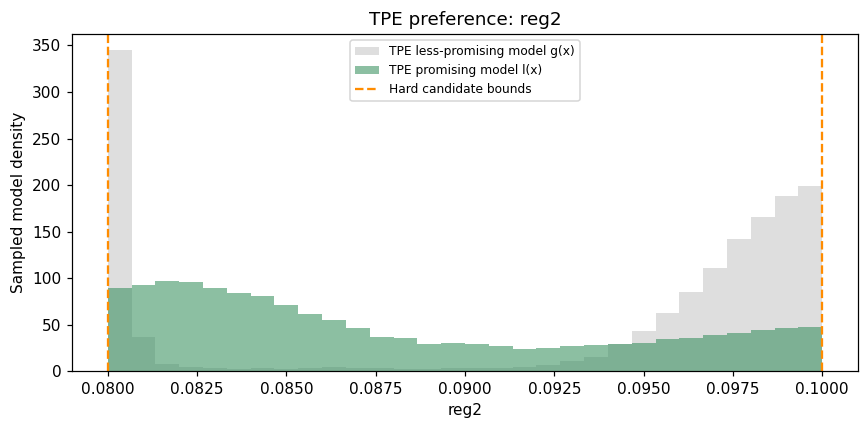

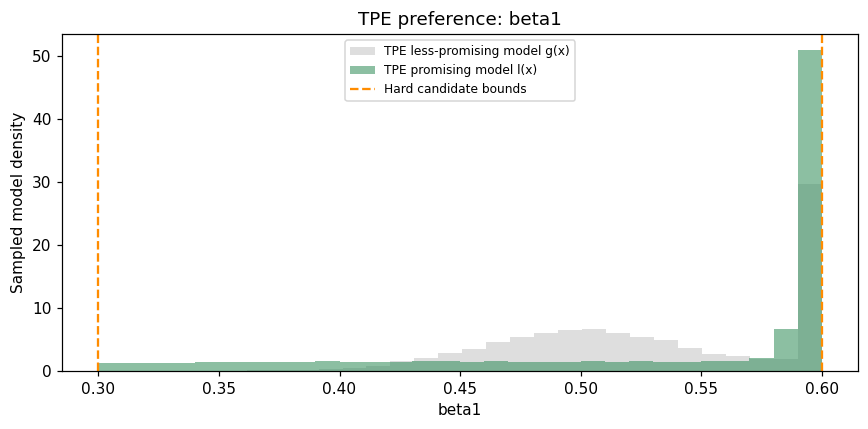

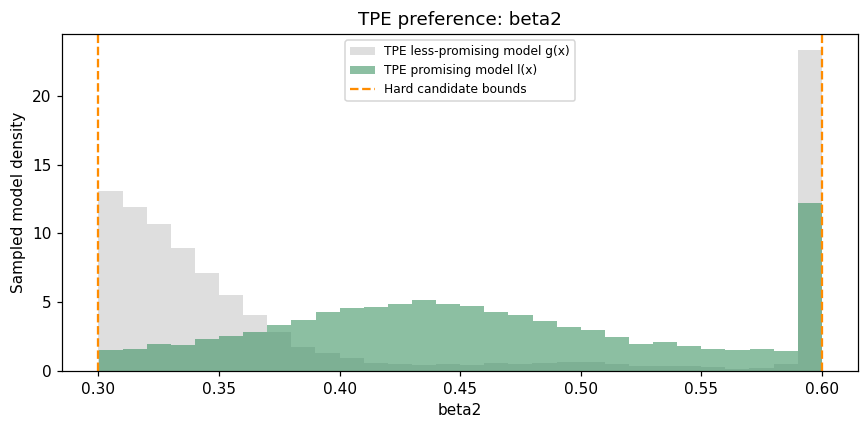

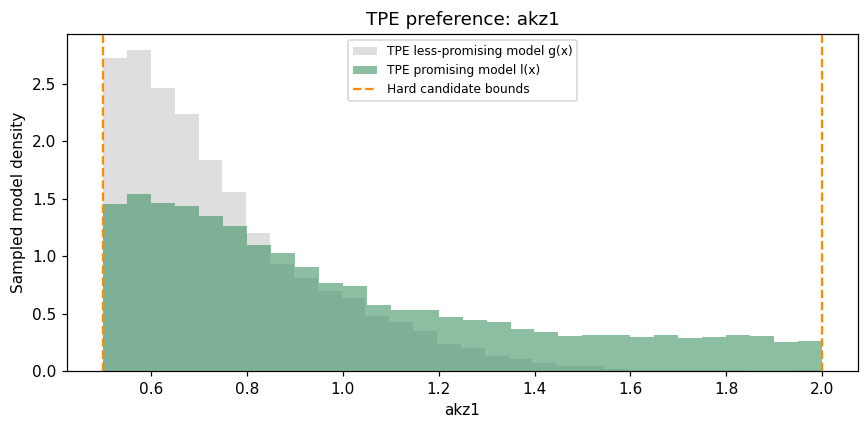

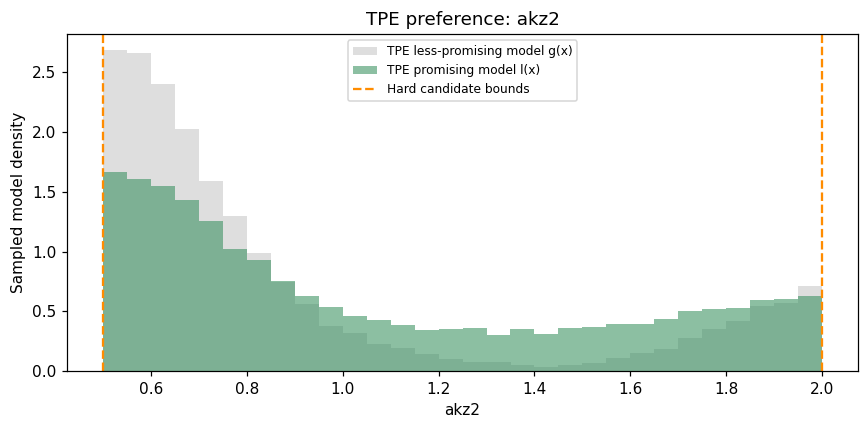

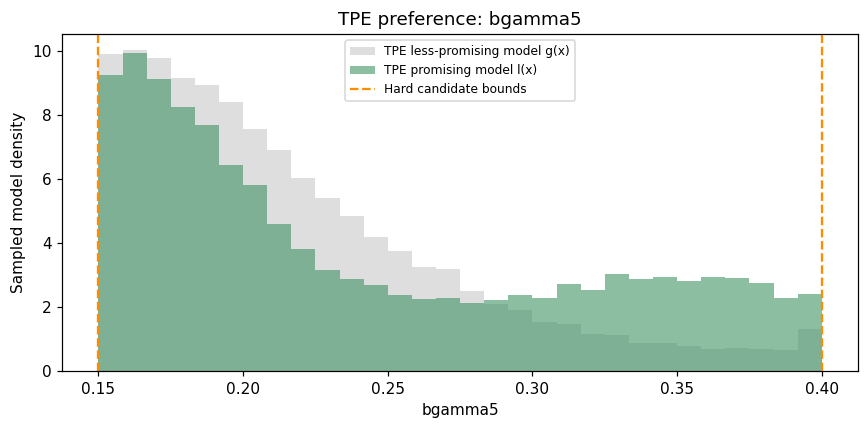

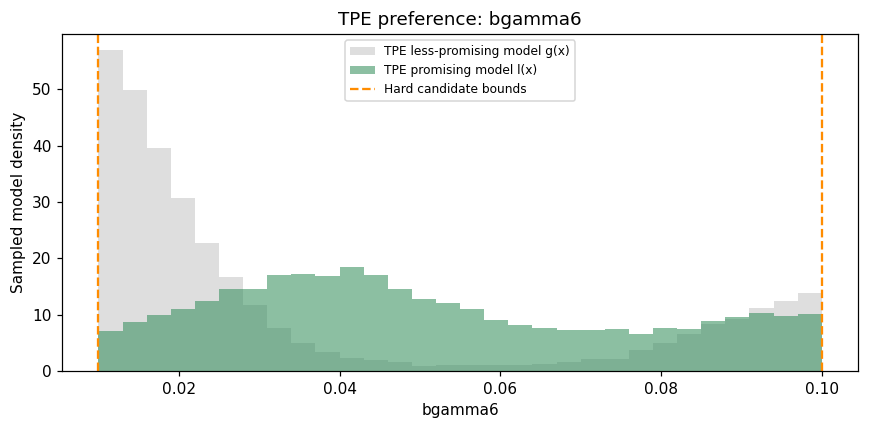

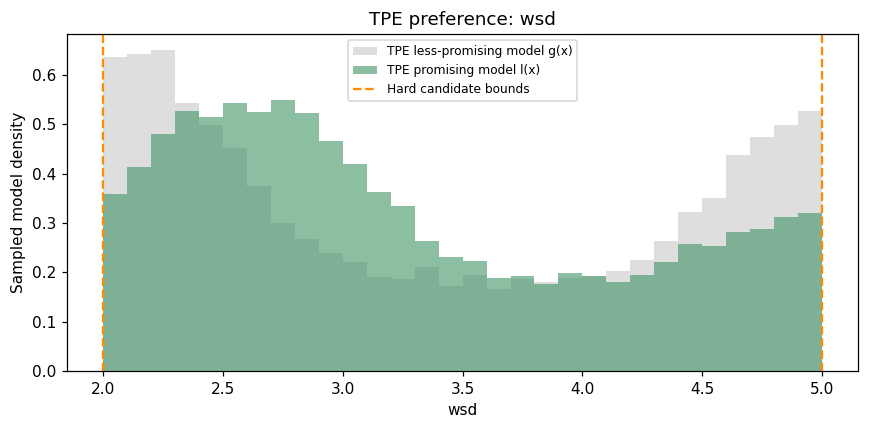

In [19]:
if study is not None and len(study.trials) > 0:
    provenance = cpu.trial_provenance_table(study)
    cpu.atomic_write_csv(provenance, OUTPUT_PATHS.trial_provenance_file, index=False)
    display(provenance["Origin"].fillna("Unknown").value_counts().rename("Trials").to_frame())
    search_space = {
        parameter: optuna.distributions.FloatDistribution(*bounds)
        for parameter, bounds in numeric_bounds.items()
    }
    search_space.update({
        parameter: optuna.distributions.CategoricalDistribution(choices)
        for parameter, choices in categorical_choices.items()
    })
    try:
        tpe_good, tpe_other, tpe_metadata = cpu.tpe_distribution_samples(
            study, study.sampler, search_space, seed=RANDOM_SEED
        )
        display(pd.DataFrame([tpe_metadata]).T.rename(columns={0: "Value"}))
        for parameter in numeric_bounds:
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(tpe_other[parameter], bins=30, density=True, color="lightgray", alpha=0.75,
                    label="TPE less-promising model g(x)")
            ax.hist(tpe_good[parameter], bins=30, density=True, color="seagreen", alpha=0.55,
                    label="TPE promising model l(x)")
            low, high = numeric_bounds[parameter]
            ax.axvline(low, color="darkorange", linestyle="--", linewidth=1.5, label="Hard candidate bounds")
            ax.axvline(high, color="darkorange", linestyle="--", linewidth=1.5)
            ax.set(xlabel=parameter, ylabel="Sampled model density", title=f"TPE preference: {parameter}")
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
        for parameter in categorical_choices:
            comparison = pd.concat([
                tpe_good[parameter].value_counts(normalize=True).rename("Promising l(x)"),
                tpe_other[parameter].value_counts(normalize=True).rename("Less-promising g(x)"),
            ], axis=1).fillna(0)
            comparison["Preference ratio l/g"] = comparison["Promising l(x)"] / comparison["Less-promising g(x)"].replace(0, np.nan)
            display(comparison)
    except (RuntimeError, ValueError) as error:
        print(f"Exact TPE diagnostic unavailable: {error}")

## 18. Write candidate ROMS input files

This section runs only in `write_inputs` mode. It uses existing RUNNING trials, applies active values, fills inactive template parameters from the selected baseline unless a fixed value is supplied in the prior table, validates replacements in memory, and then writes files under `MO-BIO/candidates/input_files/`.

CPP-option changes remain unsupported and excluded. Existing candidate files are protected unless `OVERWRITE_CANDIDATE_FILES=True`.

**How to interpret the output table:** each row confirms the exact optics and sediment files written for one candidate. Matching run names across the candidate table, both file names, and the study trial are essential provenance. The table confirms successful writing and validated substitutions; it does not confirm that ROMS has run successfully. Spot-check the first generated pair before launching a large batch.

In [20]:
if RUN_MODE == "write_inputs":
    running = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.RUNNING]
    if not running:
        raise ValueError("No RUNNING trials are available for input-file generation.")
    DF_trial_candidates = pd.DataFrame([
        {"Run Name": trial.user_attrs.get("Run Name"), "Trial Number": trial.number, **trial.params}
        for trial in running
    ])
    baseline_matches = DF_analysis.loc[DF_analysis["Run Name"].eq(BASELINE_RUN_NAME)]
    if len(baseline_matches) != 1:
        raise ValueError(f"Expected exactly one baseline run {BASELINE_RUN_NAME!r}; found {len(baseline_matches)}")
    baseline = baseline_matches.iloc[0]
    template_parameters = [
        *cpu.OPTICS_PARAMETERS, *cpu.SEDIMENT_PARAMETERS,
        BIO_NL_TNU2_PARAMETER, BIO_ADVECTION_PARAMETER,
    ]
    fixed_values = {}
    for parameter in template_parameters:
        if parameter not in baseline.index or pd.isna(baseline[parameter]) or parameter in DF_trial_candidates.columns:
            continue
        fixed_values[parameter] = (
            str(baseline[parameter]) if parameter == BIO_ADVECTION_PARAMETER
            else float(baseline[parameter])
        )
    for row in DF_priors.loc[DF_priors["decision"].eq("fixed")].itertuples(index=False):
        fixed_values[row.parameter] = cpu.parse_prior_fixed_value(row)
    optics_texts, sediment_texts = cpu.build_candidate_input_texts(
        DF_trial_candidates,
        optics_template=OPTICS_TEMPLATE,
        sediment_template=SEDIMENT_TEMPLATE,
        optics_parameters=cpu.OPTICS_PARAMETERS,
        sediment_parameters=cpu.SEDIMENT_PARAMETERS,
        fixed_values=fixed_values,
        biological_tnu2_parameter=BIO_NL_TNU2_PARAMETER,
        biological_advection_parameter=BIO_ADVECTION_PARAMETER,
        biological_advection_schemes=BIO_ADVECTION_SCHEMES,
        advection_input_codes=ADVECTION_INPUT_CODES,
        biological_tracer_count=BIOLOGICAL_TRACER_COUNT,
        remote_sediment_directory=REMOTE_SEDIMENT_DIRECTORY,
    )
    DF_written_files = cpu.write_candidate_input_files(
        optics_texts, sediment_texts, CANDIDATE_OUTPUT_DIR,
        overwrite=OVERWRITE_CANDIDATE_FILES,
    )
    display(DF_written_files)

,Run Name,Optics File,Sediment File
0,OPTUNA_BIO_MO_109,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...
1,OPTUNA_BIO_MO_110,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...
2,OPTUNA_BIO_MO_111,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...
3,OPTUNA_BIO_MO_112,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...,/Users/akbaskind/Desktop/Optimization/MO-BIO/c...


## 19. Final decision summary

Before leaving the notebook, record what is supported, what remains tentative, and what you intend to do next. The generated tables are evidence; your rationale belongs in `parameter_priors.csv` so it survives reruns.

**Do not overclaim:** a TPE preference is an optimization preference over the tested space, not proof that a parameter is scientifically correct.

**How to interpret the final table:** it is a stopping checklist, not a scorecard. Confirm that the run count is plausible, unresolved issues are understood, active-parameter counts match your intended search, and the budget assessment matches the complexity you accepted. A clean summary does not replace recording why each parameter was made active, fixed, reserved, or excluded in `parameter_priors.csv`.

In [21]:
final_summary = pd.DataFrame([
    {"Question": "Analysis-ready runs", "Answer": len(DF_analysis)},
    {"Question": "Exact Pareto runs", "Answer": int(DF_analysis["Pareto Optimal"].sum())},
    {"Question": "Active numeric parameters", "Answer": len(active_numeric_rows)},
    {"Question": "Active categorical parameters", "Answer": len(active_categorical_rows)},
    {"Question": "Parameters awaiting decision", "Answer": int(DF_priors["decision"].eq("review").sum())},
    {"Question": "Unresolved data-quality issues", "Answer": int(DF_quality_issues["resolution_status"].eq("unresolved").sum())},
    {"Question": "Budget assessment", "Answer": budget["Assessment"]},
    {"Question": "Current run mode", "Answer": RUN_MODE},
])
display(final_summary.style.hide(axis="index"))

print("Guiding principles:")
print("- Narrow ranges only when supported by multiple runs and scientific plausibility.")
print("- Treat confounded parameters and sparse categories cautiously.")
print("- Fixed for this round does not mean scientifically unimportant.")
print("- If TPE accumulates at a boundary, inspect the historical evidence; expand only if the science supports it.")
print("- Use the external guide for recovery, schema details, and future modifications.")

print(f"MO-BIO output root: {MO_BIO_OUTPUT_DIRECTORY}")
print("- Initial MO-BIO/PHYS paired runs assume temperature/salinity changes are small.")
print("- If a paired run has anomalous physical cost, interpret its biological objectives cautiously.")

Question,Answer
Analysis-ready runs,109
Exact Pareto runs,3
Active numeric parameters,9
Active categorical parameters,0
Parameters awaiting decision,0
Unresolved data-quality issues,2
Budget assessment,Focused
Current run mode,write_inputs


Guiding principles:
- Narrow ranges only when supported by multiple runs and scientific plausibility.
- Treat confounded parameters and sparse categories cautiously.
- Fixed for this round does not mean scientifically unimportant.
- If TPE accumulates at a boundary, inspect the historical evidence; expand only if the science supports it.
- Use the external guide for recovery, schema details, and future modifications.
MO-BIO output root: /Users/akbaskind/Desktop/Optimization/MO-BIO
- Initial MO-BIO/PHYS paired runs assume temperature/salinity changes are small.
- If a paired run has anomalous physical cost, interpret its biological objectives cautiously.


In [22]:
running_trials = pd.DataFrame(
  [
      {
          "Trial Number": trial.number,
          "Run Name": trial.user_attrs.get("Run Name"),
          **trial.params,
      }
      for trial in study.trials
      if trial.state == optuna.trial.TrialState.RUNNING
  ]
)

display(running_trials)

,Trial Number,Run Name,reg1,reg2,beta1,beta2,akz1,akz2,bgamma5,bgamma6,wsd
0,109,OPTUNA_BIO_MO_109,0.192434,0.094797,0.311618,0.587931,0.580820,0.847068,0.216024,0.047345,2.586717
1,110,OPTUNA_BIO_MO_110,0.150328,0.083155,0.320346,0.580669,1.534836,0.863103,0.341564,0.063689,2.936621
2,111,OPTUNA_BIO_MO_111,0.149604,0.094151,0.314749,0.562326,1.629837,0.609319,0.330844,0.033903,3.048717
3,112,OPTUNA_BIO_MO_112,0.139872,0.083390,0.307665,0.359713,1.495110,0.575389,0.349499,0.053680,3.133745
